# Lab 6: 从零搞懂 Attention、Transformer 与 Qwen3-Next


<img src="./images/qwen3-next-benchmark.jpeg" width="760"/>

## 目标

1. 先把 **Attention 与 Transformer** 讲清楚；
2. 再一步步走到 **Qwen3-Next** 的混合注意力、MoE 与 MTP；
3. 所有代码都尽量基于 **PyTorch 原生实现**；
4. 后面的模块会尽量**复用前面已经写过的代码**，怎样逐步“叠起来”每一份代码。

## 目录

- **第 1–3 章**：从 Q / K / V 到 Multi-Head，再到标准 Transformer block。
- **第 4 章**：先讲 MoE，再讲 Sparse MoE。这一章会比其它章更长，因为很多学生第一次接触 MoE。
- **第 5 章**：用一个 **toy 的长位数加法数据集** 训练 MTP，让你看到“多步预测”到底在做什么。
- **第 6 章**：定义一个 **0.01B 级别的 Qwen3-Next 风格项目任务**，要求用 `transformers` 中的 Qwen3-Next 代码为核心。
- **第 7 章**：在系统层面，使用 DeepSpeed 加速训练、最后用 vLLM 跑 `/v1` 接口。

## 任务

- **问题一**：给出Qwen3-Next的两种参数配置，判断哪种配置更为合理？因为什么？
- **问题二**：Tokenizer为什么要加special tokens，分别是什么意思？
- **问题三**：做完整个tutorial你的收获是什么？

In [1]:
# 建议环境（仅展示，不强制立即运行）
# !pip install -U torch torchvision torchaudio
# !pip install -U tqdm matplotlib tokenizers sentencepiece datasets
# !pip install -U git+https://github.com/huggingface/transformers.git
# !pip install -U deepspeed vllm


# 第 1 章　Transformer (从 Q/K/V 到 Multi-Head Attention)

本章目标：从最基础的点积注意力开始，逐步构建到多头注意力，为后续 Transformer block 打下基础。

---

## 1.1 点积注意力 (Dot-Product Attention)

如果把注意力机制压缩成一句话，那就是：

> **给定一个 Query，用 Key 来匹配，再把最相关的 Value 聚合出来。**

<img src="./images/qkv_attention_mechanism.svg" width="800"/>

### 核心思想
query 不直接比较 value，而是先通过 key 找到最相关的信息，再提取其 value

公式为：
$$
Attention(Q, K, V) = softmax( Q·Kᵀ / √dₖ ) · V
$$

从左到右分五个阶段：
1. Query（查询） — 当前 token 的向量表示，负责"提问"
2. Keys（键） — 所有 token 的键向量，用于"匹配"；query 与每个 key 做点积计算相似度
3. 相似度得分 — 点积结果除以 √d_k（防止梯度消失），k2 得分最高（0.81）
4. Softmax 权重 — 将得分归一化为概率分布（权重条形图），k2 获得 81% 的注意力权重
5. Values（值） → Output — 按权重对 value 向量加权求和，高权重的 v2 主导输出


In [1]:
import torch
import torch.nn.functional as F

# ========== 示例 1：最简注意力（单个 query） ==========
# 一个 query：表示"当前时刻想找什么"
q = torch.tensor([[1.0, 0.0]])

# 三个 key：表示"候选位置分别长什么样"
K = torch.tensor([[1.0, 0.0],
                  [0.0, 1.0],
                  [-1.0, 0.0]])

# 三个 value：表示"候选位置真正携带的内容"
V = torch.tensor([[10.0,  0.0],
                  [ 0.0,  8.0],
                  [-6.0,  0.0]])

# 第一步：计算 query 和每个 key 的相似度（点积）
scores = q @ K.T
print('scores =', scores)

# 第二步：把分数变成权重（softmax 归一化）
weights = torch.softmax(scores, dim=-1)
print('weights =', weights)

# 第三步：用这些权重去加权求和 value
output = weights @ V
print('output =', output)

scores = tensor([[ 1.,  0., -1.]])
weights = tensor([[0.6652, 0.2447, 0.0900]])
output = tensor([[6.1122, 1.9578]])


### Shape 小结

- `Q`: `[1, d]`
- `K`: `[n, d]`
- `V`: `[n, d_v]`
- `scores`: `[1, n]`
- `weights`: `[1, n]`
- `output`: `[1, d_v]`

In [2]:
# ========== 示例 2：批量点积注意力（两个不同序列） ==========
# 创建两个张量 x1 和 x2，代表两个不同的序列，这里x1相当于Q，x2相当于K和V
x1 = torch.randn(2, 3, 4)  # 形状 (batch_size, seq_len1, feature_dim)
x2 = torch.randn(2, 5, 4)  # 形状 (batch_size, seq_len2, feature_dim)

# 计算原始权重：x1 的每个 token 与 x2 的每个 token 的相似度
raw_weights = torch.bmm(x1, x2.transpose(1, 2))  # 形状 (batch_size, seq_len1, seq_len2)
print('raw_weights shape =', raw_weights.shape)

# 用 softmax 函数对原始权重进行归一化
attn_weights = F.softmax(raw_weights, dim=2)  # 形状 (batch_size, seq_len1, seq_len2)

# 将注意力权重与 x2 相乘，计算加权和
attn_output = torch.bmm(attn_weights, x2)  # 形状 (batch_size, seq_len1, feature_dim)
print('attn_output shape =', attn_output.shape)

raw_weights shape = torch.Size([2, 3, 5])
attn_output shape = torch.Size([2, 3, 4])


---

## 1.2 缩放点积注意力 (Scaled Dot-Product Attention)

### 为什么要缩放？

当特征维度 $d$ 较大时，点积的数值会很大，导致 softmax 函数进入梯度极小的饱和区。除以 $\sqrt{d}$ 可以让分数的尺度更稳定。

$$
\operatorname{score}(Q, K) = \frac{QK^\top}{\sqrt{d}}
$$

<img src="./images/scaled_dot_product_attention.png" width="360"/>

In [3]:
import torch
import torch.nn.functional as F

# ========== 示例：缩放点积注意力 ==========
#1. 创建 Query、Key 和 Value 张量
q = torch.randn(2, 3, 4) # 形状 (batch_size, seq_len1, feature_dim)
k = torch.randn(2, 4, 4) # 形状 (batch_size, seq_len2, feature_dim)
v = torch.randn(2, 4, 4) # 形状 (batch_size, seq_len2, feature_dim)
# 2. 计算点积，得到原始权重，形状为 (batch_size, seq_len1, seq_len2)
raw_weights = torch.bmm(q, k.transpose(1, 2))
# 3. 将原始权重进行缩放（可选），形状仍为 (batch_size, seq_len1, seq_len2)
scaling_factor = q.size(-1) ** 0.5
scaled_weights = raw_weights / scaling_factor
# 4. 应用 softmax 函数，使结果的值在 0 和 1 之间，且每一行的和为 1
attn_weights = F.softmax(scaled_weights, dim=-1) # 形状仍为 (batch_size, seq_len1, seq_len2)
# 5. 与 Value 相乘，得到注意力分布的加权和 , 形状为 (batch_size, seq_len1, feature_dim)
attn_output = torch.bmm(attn_weights, v)
print('scaled dot-product attn_output shape =', attn_output.shape)

scaled dot-product attn_output shape = torch.Size([2, 3, 4])



验证 attend:
weights shape = torch.Size([1, 2, 3])
output shape  = torch.Size([1, 2, 2])


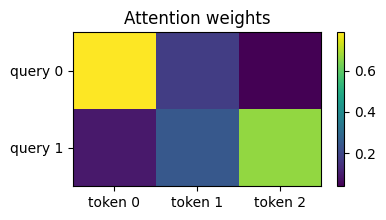

In [6]:
# ========== 可复用函数 ==========
def attend(scores, V):
    """根据相似度分数，用 softmax 计算各 Value 的权重，并加权求和得到输出

    Args:
        scores: [B, Q, T] - Query 与 Key 的相似度分数
        V:      [B, T, Dv] - Value 矩阵

    Returns:
        output: [B, T, Dv] - 加权求和后的输出
        weights: [B, T, D] - softmax 后的注意力权重
    """
    weights = torch.softmax(scores, dim=-1)
    output = weights @ V
    return output, weights


# 验证函数
scores = torch.tensor([[[ 2.0,  0.5, -1.0],
                        [ 0.0,  1.0,  2.0]]])   # [B=1, Q=2, D=3]
V = torch.tensor([[[10.0, 0.0],
                   [ 0.0, 5.0],
                   [-2.0, 1.0]]])              # [B=1, D=3, Dv=2]

output, weights = attend(scores, V)
print('\n验证 attend:')
print('weights shape =', weights.shape)  # [1, 2, 3]
print('output shape  =', output.shape)   # [1, 2, 2]

import matplotlib.pyplot as plt

# 热力图能帮助初学者看到"权重到底分配到了哪里"
plt.figure(figsize=(4, 2))
plt.imshow(weights[0].numpy(), aspect='auto')
plt.yticks([0, 1], ['query 0', 'query 1'])
plt.xticks([0, 1, 2], ['token 0', 'token 1', 'token 2'])
plt.colorbar()
plt.title('Attention weights')
plt.show()

---

## 1.3 自注意力 (Self-Attention)

### 什么是自注意力？

自注意力是一种特殊的注意力机制，其中 Query、Key、Value 都来自**同一个输入序列**。这让序列中的每个位置都能"看到"其他所有位置，并决定应该关注哪些信息。

In [7]:
# ========== 示例 1：最简单的自注意力 ==========
import torch
import torch.nn.functional as F
# 一个形状为 (batch_size, seq_len, feature_dim) 的张量 x
x = torch.randn(2, 3, 4)
# 计算原始权重，形状为 (batch_size, seq_len, seq_len)
raw_weights = torch.bmm(x, x.transpose(1, 2))
# 对原始权重进行 softmax 归一化，形状为 (batch_size, seq_len, seq_len)
attn_weights = F.softmax(raw_weights, dim=2)
# 计算加权和，形状为 (batch_size, seq_len, feature_dim) 
attn_outputs = torch.bmm(attn_weights, x)
print('self-attention output shape =', attn_outputs.shape)

self-attention output shape = torch.Size([2, 3, 4])


In [8]:
# ========== 示例 2：缩放点积自注意力 ==========
# 一个形状为 (batch_size, seq_len, feature_dim) 的张量 x
x = torch.randn(2, 3, 4) # 形状 (batch_size, seq_len, feature_dim)
# 定义线性层用于将 x 转换为 Q, K, V 向量
linear_q = torch.nn.Linear(4, 4)
linear_k = torch.nn.Linear(4, 4)
linear_v = torch.nn.Linear(4, 4)
# 通过线性层计算 Q, K, V
Q = linear_q(x) # 形状 (batch_size, seq_len, feature_dim)
K = linear_k(x) # 形状 (batch_size, seq_len, feature_dim)
V = linear_v(x) # 形状 (batch_size, seq_len, feature_dim)
# 计算 Q 和 K 的点积，作为相似度分数 , 也就是自注意力原始权重
raw_weights = torch.bmm(Q, K.transpose(1, 2)) # 形状 (batch_size, seq_len, seq_len)
# 将自注意力原始权重进行缩放
scale_factor = K.size(-1) ** 0.5  # 这里是 4 ** 0.5
scaled_weights = raw_weights / scale_factor # 形状 (batch_size, seq_len, seq_len)
# 对缩放后的权重进行 softmax 归一化，得到注意力权重
attn_weights = F.softmax(scaled_weights, dim=2) # 形状 (batch_size, seq_len, seq_len)
# 将注意力权重应用于 V 向量，计算加权和，得到加权信息
attn_outputs = torch.bmm(attn_weights, V) # 形状 (batch_size, seq_len, feature_dim)
print(" 加权信息 :", attn_outputs)

 加权信息 : tensor([[[-0.0619, -0.1511, -0.1211,  0.1611],
         [-0.3694, -0.0357, -0.0438,  0.2416],
         [-0.4874, -0.0169,  0.0150,  0.2792]],

        [[-0.3472, -0.3688,  0.3178,  0.0926],
         [-0.4267, -0.3612,  0.5872,  0.3729],
         [-0.3735, -0.3522,  0.4242,  0.2162]]], grad_fn=<BmmBackward0>)


In [11]:
import math

# ========== 可复用函数：标准缩放点积注意力 ==========
def scaled_dot_product_attention(Q, K, V, mask=None):
    """标准缩放点积注意力，这里的h指的是注意力头数量，后面会讲解多头注意力

    Args:
        Q: [B, Q, d] 或 [B, h, Q, d] - Query 矩阵
        K: [B, T, d] 或 [B, h, T, d] - Key 矩阵
        V: [B, T, dv] 或 [B, h, T, dv] - Value 矩阵
        mask: [T, T] 或 [B, h, T, T] - 可选的掩码矩阵

    Returns:
        output: 加权求和后的输出
        weights: softmax 后的注意力权重
    """

    # 计算缩放点积分数
    scores = (Q @ K.transpose(-1, -2)) / math.sqrt(Q.shape[-1])

    # 如果提供了 mask，应用 mask（利用广播机制）
    if mask is not None:
        scores = scores + mask

    # softmax 归一化得到注意力权重
    weights = torch.softmax(scores, dim=-1)

    # 加权求和
    output = weights @ V
    return output, weights


## 1.4 Causal Mask（因果掩码）

语言模型训练时，当前位置不能"偷看"未来 token。因此必须加一个 **causal mask**，让每个位置只能看到自己和左边的 token。

<img src="./images/causal_mask_attention.svg" width="600"/>

标准公式是：

$$
\operatorname{Attn}(Q, K, V) = \operatorname{softmax}\left(\frac{QK^\top + M}{\sqrt{d}}\right)V
$$

其中 $M$ 是一个上三角为 $-\infty$ 的 mask。这样 softmax 之后，未来位置的权重就会变成 0。

In [12]:
# ========== 生成因果掩码 ==========
def make_causal_mask(seq_len, device=None):
    """
    生成因果掩码（Causal Mask），防止模型看到"未来"的 token。
    
    什么是因果掩码？
        在语言模型中，预测第 i 个词时，只能看到第 0~i-1 个词。
        用一个矩阵来表示"哪些位置可以看、哪些不能看"：
            - 0    表示"可以看"（保留原始注意力分数）
            - -inf 表示"不能看"（softmax 后趋近于 0，相当于忽略）

    Args:
        seq_len: 序列长度（生成 seq_len × seq_len 的方阵）
        device:  张量存放的设备（如 'cpu' 或 'cuda'）

    Returns:
        mask: [seq_len, seq_len] 的矩阵，上三角为 -inf，其余为 0
    
    例如 seq_len=4 时，返回：
        [  0, -inf, -inf, -inf ]   ← 位置0，只能看自己
        [  0,    0, -inf, -inf ]   ← 位置1，能看0和1
        [  0,    0,    0, -inf ]   ← 位置2，能看0、1、2
        [  0,    0,    0,    0 ]   ← 位置3，能看所有
    """

    # 第一步：建一个全是 -inf 的 seq_len × seq_len 矩阵
    # 先"悲观"地假设所有位置都不可见
    all_masked = torch.full(
        size=(seq_len, seq_len),
        fill_value=float('-inf'),
        device=device
    )

    # 第二步：用 triu 只保留"上三角"部分的 -inf
    # diagonal=1 表示从主对角线往上一格开始保留
    # 主对角线及以下全部变为 0（可以看）
    #
    # torch.triu 示意（seq_len=4）：
    #   输入全 -inf            输出（diagonal=1）
    #   -inf -inf -inf -inf      0  -inf -inf -inf
    #   -inf -inf -inf -inf  →   0     0  -inf -inf
    #   -inf -inf -inf -inf      0     0     0  -inf
    #   -inf -inf -inf -inf      0     0     0     0
    causal_mask = torch.triu(all_masked, diagonal=1)

    return causal_mask

In [13]:
mask = make_causal_mask(seq_len=5)
print('\nCausal mask (5x5):')
print(mask)

# ========== 示例：带 causal mask 的自注意力 ==========
x = torch.randn(2, 5, 4)  # [B=2, T=5, d=4]
Q, K, V = x, x, x  # self-attention: Q / K / V 都来自同一个序列
mask = make_causal_mask(seq_len=x.size(1), device=x.device)

output, weights = scaled_dot_product_attention(Q, K, V, mask)
print('\nCausal self-attention:')
print('output shape  =', output.shape)
print('weights shape =', weights.shape)


Causal mask (5x5):
tensor([[0., -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0.]])

Causal self-attention:
output shape  = torch.Size([2, 5, 4])
weights shape = torch.Size([2, 5, 5])


# 第 2 章　从单头到多头：Multi-Head Attention 与 Transformer Block

## 本章问题

单头注意力已经能工作了，为什么还要多头？

因为一个头只能在一个子空间里做匹配；多头则相当于把输入投到**多个子空间**里，让不同头各自学习不同关系，再把它们拼起来。

<img src="./images/multi_head_attention.svg" width="800"/>

### 核心操作

1. **分头 (Split Heads)**：将 Q/K/V 从 `[B, T, H]` 变换为 `[B, num_heads, T, head_dim]`
2. **并行计算**：每个头独立计算注意力
3. **拼接 (Combine Heads)**：将所有头的结果拼接回 `[B, T, H]`


In [14]:
# ========== 多头自注意力的分步实现 ==========

# 一个形状为 (batch_size, seq_len, feature_dim) 的张量 x
x = torch.randn(2, 3, 8)  # 形状 (batch_size, seq_len, feature_dim)

# 定义头数和每个头的维度
num_heads = 2
head_dim = 4

# feature_dim 必须是 num_heads * head_dim 的整数倍
assert x.size(-1) == num_heads * head_dim

# 定义线性层用于将 x 转换为 Q, K, V 向量
linear_q = torch.nn.Linear(8, 8)
linear_k = torch.nn.Linear(8, 8)
linear_v = torch.nn.Linear(8, 8)

# 通过线性层计算 Q, K, V
Q = linear_q(x)  # 形状 (batch_size, seq_len, feature_dim)
K = linear_k(x)  # 形状 (batch_size, seq_len, feature_dim)
V = linear_v(x)  # 形状 (batch_size, seq_len, feature_dim)

# 将 Q, K, V 分割成 num_heads 个头
def split_heads(tensor, num_heads):
    batch_size, seq_len, feature_dim = tensor.size()
    head_dim = feature_dim // num_heads
    output = tensor.view(batch_size, seq_len, num_heads, head_dim).transpose(1, 2)
    return output  # 形状 (batch_size, num_heads, seq_len, head_dim)

Q = split_heads(Q, num_heads)  # 形状 (batch_size, num_heads, seq_len, head_dim)
K = split_heads(K, num_heads)  # 形状 (batch_size, num_heads, seq_len, head_dim)
V = split_heads(V, num_heads)  # 形状 (batch_size, num_heads, seq_len, head_dim)

# 计算 Q 和 K 的点积，作为相似度分数
raw_weights = torch.matmul(Q, K.transpose(-2, -1))  # 形状 (batch_size, num_heads, seq_len, seq_len)

# 对自注意力原始权重进行缩放
scale_factor = K.size(-1) ** 0.5
scaled_weights = raw_weights / scale_factor

# 对缩放后的权重进行 softmax 归一化
attn_weights = F.softmax(scaled_weights, dim=-1)

# 将注意力权重应用于 V 向量
attn_outputs = torch.matmul(attn_weights, V)  # 形状 (batch_size, num_heads, seq_len, head_dim)

# 将所有头的结果拼接起来
def combine_heads(tensor, num_heads):
    batch_size, num_heads, seq_len, head_dim = tensor.size()
    feature_dim = num_heads * head_dim
    output = tensor.transpose(1, 2).contiguous().view(batch_size, seq_len, feature_dim)
    return output  # 形状 (batch_size, seq_len, feature_dim)

attn_outputs = combine_heads(attn_outputs, num_heads)

# 对拼接后的结果进行线性变换
linear_out = torch.nn.Linear(8, 8)
attn_outputs = linear_out(attn_outputs)
print('multi-head attention output shape =', attn_outputs.shape)

multi-head attention output shape = torch.Size([2, 3, 8])


### 本章小结

后面你会看到：

- 标准 Transformer block 会直接用 `MultiHeadSelfAttention`；
- Gated Attention 会在这个类的基础上再加一条 **gate 分支**；
- MTP 训练时，backbone 也会复用这些 block。


### 把 Multi-Head 拼成一个标准 Transformer block


到这里我们已经有了一个能工作的 `MultiHeadSelfAttention`。下一步就是把它和 FFN、残差连接、LayerNorm 拼起来，得到一个最小的 Transformer 解码器 block。

<img src="./images/transformer.svg" width="800"/>

这一章最重要的收获不是“看懂一张图”，而是写出一个能反复复用的 `TransformerBlock`。


#### 组件1 多头自注意力

In [12]:
import torch.nn as nn
# 定义多头自注意力类
class MultiHeadAttention(nn.Module):
    def __init__(self, hidden_size, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert hidden_size % num_heads == 0
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.head_dim = hidden_size // num_heads # 标准Transformer中d_k和d_v始终相等，用head_dim表示
        self.W_Q = nn.Linear(hidden_size, self.hidden_size) # Q的线性变换层
        self.W_K = nn.Linear(hidden_size, self.hidden_size) # K的线性变换层
        self.W_V = nn.Linear(hidden_size, self.hidden_size) # V的线性变换层
        self.linear = nn.Linear(hidden_size, self.hidden_size)
        self.layer_norm = nn.LayerNorm(self.hidden_size)
    def forward(self, Q, K, V, attn_mask): 
        #------------------------- 维度信息 -------------------------------- 
        # Q K V [batch_size, len_q/k/v, hidden_size] 
        #-----------------------------------------------------------------        
        residual, batch_size = Q, Q.size(0) # 保留残差连接
        # 将输入进行线性变换和重塑，以便后续处理
        q_s = self.W_Q(Q).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1,2)        
        k_s = self.W_K(K).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1,2)
        v_s = self.W_V(V).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1,2)
        #------------------------- 维度信息 -------------------------------- 
        # q_s k_s v_s: [batch_size, num_heads, len_q/k/v, head_dim]
        #----------------------------------------------------------------- 
        # 处理传入的 attn_mask: [batch_size, len_q, len_k] -> [batch_size, 1, len_q, len_k]
        # 布尔类型转换为数值类型: True(padding) -> -inf, False(有效) -> 0
        if attn_mask is not None:
            # 扩展维度以适配多头: [batch_size, 1, len_q, len_k]
            attn_mask = attn_mask.unsqueeze(1)
        #------------------------- 维度信息 -------------------------------- 
        # attn_mask [batch_size, num_heads, len_q, len_k] (通过广播)
        #----------------------------------------------------------------- 
        # 使用缩放点积注意力计算上下文和注意力权重
        context, weights = scaled_dot_product_attention(q_s, k_s, v_s, attn_mask)
        #------------------------- 维度信息 -------------------------------- 
        # context [batch_size, num_heads, len_q, dim_v]
        # weights [batch_size, num_heads, len_q, len_k]
        #----------------------------------------------------------------- 
        # 通过调整维度将多个头的上下文向量连接在一起
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.hidden_size) 
        #------------------------- 维度信息 -------------------------------- 
        # context [batch_size, len_q, n_heads * dim_v]
        #-----------------------------------------------------------------        
        # 用一个线性层把连接后的多头自注意力结果转换，原始地嵌入维度
        output = self.linear(context) 
        #------------------------- 维度信息 -------------------------------- 
        # output [batch_size, len_q, hidden_size]
        #-----------------------------------------------------------------        
        # 与输入 (Q) 进行残差链接，并进行层归一化后输出
        output = self.layer_norm(output + residual)
        #------------------------- 维度信息 -------------------------------- 
        # output [batch_size, len_q, hidden_size]
        #-----------------------------------------------------------------        
        return output, weights # 返回层归一化的输出和注意力权重



#### 组件2 逐位置前馈网络（包含残差连接和层归一化）

In [13]:
# ========== 原始版本 ==========
# 定义逐位置前馈网络类
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, hidden_size, intermediate_size):
        super(PoswiseFeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(hidden_size, intermediate_size)  # 第一层：升维
        self.fc2 = nn.Linear(intermediate_size, hidden_size)  # 第二层：降维
        self.relu = nn.ReLU()
        self.layer_norm = nn.LayerNorm(hidden_size)

    def forward(self, x):
        #------------------------- 维度信息 --------------------------------
        # x: [batch_size, len_q, hidden_size]
        #-----------------------------------------------------------------
        residual = x

        # 第一层：升维
        output = self.fc1(x)
        #------------------------- 维度信息 --------------------------------
        # output: [batch_size, len_q, intermediate_size]
        #-----------------------------------------------------------------

        # 激活函数
        output = self.relu(output)

        # 第二层：降维
        output = self.fc2(output)
        #------------------------- 维度信息 --------------------------------
        # output: [batch_size, len_q, hidden_size]
        #-----------------------------------------------------------------

        # 残差连接 + 层归一化
        output = self.layer_norm(output + residual)
        #------------------------- 维度信息 --------------------------------
        # output: [batch_size, len_q, hidden_size]
        #-----------------------------------------------------------------

        return output

In [14]:
# ========== 卷积优化版本 ==========
# 定义逐位置前馈网络类
class PoswiseFeedForwardNetConv(nn.Module):
    def __init__(self, hidden_size, intermediate_size=2048):
        super(PoswiseFeedForwardNetConv, self).__init__()
        # 定义一维卷积层 1，用于将输入映射到更高维度
        self.conv1 = nn.Conv1d(in_channels=hidden_size, out_channels=intermediate_size, kernel_size=1)
        # 定义一维卷积层 2，用于将输入映射回原始维度
        self.conv2 = nn.Conv1d(in_channels=intermediate_size, out_channels=hidden_size, kernel_size=1)
        # 定义层归一化
        self.layer_norm = nn.LayerNorm(hidden_size)
    def forward(self, inputs): 
        #------------------------- 维度信息 -------------------------------- 
        # inputs [batch_size, len_q, hidden_size]
        #----------------------------------------------------------------                       
        residual = inputs  # 保留残差连接 
        # 在卷积层 1 后使用 ReLU 激活函数 
        output = nn.ReLU()(self.conv1(inputs.transpose(1, 2))) 
        #------------------------- 维度信息 -------------------------------- 
        # output [batch_size, intermediate_size, len_q]
        #----------------------------------------------------------------
        # 使用卷积层 2 进行降维 
        output = self.conv2(output).transpose(1, 2) 
        #------------------------- 维度信息 -------------------------------- 
        # output [batch_size, len_q, hidden_size]
        #----------------------------------------------------------------
        # 与输入进行残差链接，并进行层归一化
        output = self.layer_norm(output + residual) 
        #------------------------- 维度信息 -------------------------------- 
        # output [batch_size, len_q, hidden_size]
        #----------------------------------------------------------------
        return output # 返回加入残差连接后层归一化的结果

#### 组件3 正弦位置编码表

In [15]:
# 生成正弦位置编码表的函数，用于在 Transformer 中引入位置信息
def get_sinusoid_encoding_table(max_len, hidden_size):
    """
    正弦位置编码是什么？
        Transformer 没有循环结构，无法感知 token 的位置顺序。
        通过给每个位置加上一个固定的位置向量，让模型知道每个 token 在序列中的位置。
    
    编码公式：
        PE(pos, 2i)   = sin(pos / 10000^(2i / hidden_size))  ← 偶数维度用 sin
        PE(pos, 2i+1) = cos(pos / 10000^(2i / hidden_size))  ← 奇数维度用 cos

    Args:
        max_len:     序列最大长度
        hidden_size: 每个位置的编码维度（和词向量维度相同）

    Returns:
        encoding_table: [max_len, hidden_size] 的位置编码表
    
    例如 max_len=3, hidden_size=4 时，返回：
        位置0: [ sin(0/1), cos(0/1), sin(0/100), cos(0/100) ]
        位置1: [ sin(1/1), cos(1/1), sin(1/100), cos(1/100) ]
        位置2: [ sin(2/1), cos(2/1), sin(2/100), cos(2/100) ]
    """

    # 第一步：生成位置索引 [max_len, 1]
    position = torch.arange(0, max_len).unsqueeze(1).float()
    #------------------------- 维度信息 --------------------------------
    # position: [max_len, 1]
    #-----------------------------------------------------------------

    # 第二步：生成维度索引，计算分母 [hidden_size // 2]
    # 公式：10000^(2i / hidden_size)
    div_term = torch.pow(
        10000.0,
        torch.arange(0, hidden_size, 2).float() / hidden_size
    )
    #------------------------- 维度信息 --------------------------------
    # div_term: [hidden_size // 2]
    #-----------------------------------------------------------------

    # 第三步：初始化编码表，填入 sin 和 cos
    encoding_table = torch.zeros(max_len, hidden_size)
    encoding_table[:, 0::2] = torch.sin(position / div_term)  # 偶数维度
    encoding_table[:, 1::2] = torch.cos(position / div_term)  # 奇数维度
    #------------------------- 维度信息 --------------------------------
    # encoding_table: [max_len, hidden_size]
    #-----------------------------------------------------------------

    return encoding_table

#### 当前主流位置编码：RoPE（旋转位置编码）

In [16]:
import torch

def get_rope_freqs(head_dim, max_len, base=10000, device=None):
    """
    预计算 RoPE 的 cos 和 sin 表。

    RoPE 是什么？
        不像正弦编码直接加到词向量上，RoPE 把位置信息"旋转"进 Q 和 K。
        两个向量做点积时，结果只取决于它们的相对距离，不受绝对位置影响。

    编码公式：
        theta_i = 1 / (base ^ (2i / head_dim))   ← 每对维度的旋转频率
        angle    = position * theta_i             ← 位置 × 频率 = 旋转角度

    Args:
        head_dim: 每个注意力头的维度（必须是偶数）
        max_len:  序列最大长度
        base:     旋转基数，默认 10000
        device:   张量存放的设备

    Returns:
        cos: [max_len, head_dim] - 旋转角度的余弦值
        sin: [max_len, head_dim] - 旋转角度的正弦值
    """

    # 第一步：计算每对维度的旋转频率 [head_dim // 2]
    # i = 0, 2, 4, ..., head_dim-2
    theta = 1.0 / torch.pow(
        base,
        torch.arange(0, head_dim, 2).float() / head_dim
    ).to(device)
    #------------------------- 维度信息 --------------------------------
    # theta: [head_dim // 2]
    #-----------------------------------------------------------------

    # 第二步：计算每个位置的旋转角度 [max_len, head_dim // 2]
    position = torch.arange(max_len, device=device).float()
    angles = torch.outer(position, theta)  # 外积：每个位置 × 每个频率
    #------------------------- 维度信息 --------------------------------
    # angles: [max_len, head_dim // 2]
    #-----------------------------------------------------------------

    # 第三步：拼接成完整维度，偶数和奇数列共用同一角度
    angles = torch.cat([angles, angles], dim=-1)
    #------------------------- 维度信息 --------------------------------
    # angles: [max_len, head_dim]
    #-----------------------------------------------------------------

    return angles.cos(), angles.sin()


def rotate_half(x):
    """
    将向量后半部分取负并和前半部分交换，用于实现旋转操作。

    例如 [a, b, c, d] → [-c, -d, a, b]
    """
    half = x.shape[-1] // 2
    x1 = x[..., :half]   # 前半部分
    x2 = x[..., half:]   # 后半部分
    return torch.cat([-x2, x1], dim=-1)


def apply_rope(q, k, cos, sin):
    """
    将 RoPE 旋转应用到 Q 和 K 上。

    旋转公式：
        q_rotated = q * cos + rotate_half(q) * sin

    Args:
        q:   [batch_size, num_heads, len_q, head_dim]
        k:   [batch_size, num_heads, len_k, head_dim]
        cos: [max_len, head_dim]
        sin: [max_len, head_dim]

    Returns:
        q_rotated: [batch_size, num_heads, len_q, head_dim]
        k_rotated: [batch_size, num_heads, len_k, head_dim]
    """

    len_q = q.shape[2]
    len_k = k.shape[2]

    # 截取当前序列长度对应的 cos/sin，并扩展维度用于广播
    cos_q = cos[:len_q].unsqueeze(0).unsqueeze(0)  # [1, 1, len_q, head_dim]
    sin_q = sin[:len_q].unsqueeze(0).unsqueeze(0)
    cos_k = cos[:len_k].unsqueeze(0).unsqueeze(0)  # [1, 1, len_k, head_dim]
    sin_k = sin[:len_k].unsqueeze(0).unsqueeze(0)

    q_rotated = q * cos_q + rotate_half(q) * sin_q
    k_rotated = k * cos_k + rotate_half(k) * sin_k
    #------------------------- 维度信息 --------------------------------
    # q_rotated: [batch_size, num_heads, len_q, head_dim]
    # k_rotated: [batch_size, num_heads, len_k, head_dim]
    #-----------------------------------------------------------------

    return q_rotated, k_rotated

#### 组件4 填充掩码

In [17]:
# 定义填充注意力掩码函数
def get_attn_pad_mask(seq_q, seq_k):
    #------------------------- 维度信息 --------------------------------
    # seq_q 的维度是 [batch_size, len_q]
    # seq_k 的维度是 [batch_size, len_k]
    #-----------------------------------------------------------------
    batch_size, len_q = seq_q.size()
    batch_size, len_k = seq_k.size()
    # 生成布尔类型张量
    pad_attn_mask = seq_k.data.eq(0).unsqueeze(1)  # <PAD>token 的编码值为 0
    #------------------------- 维度信息 --------------------------------
    # pad_attn_mask 的维度是 [batch_size，1，len_k]
    #-----------------------------------------------------------------
    # 变形为与注意力分数相同形状的张量 
    pad_attn_mask = pad_attn_mask.expand(batch_size, len_q, len_k).float()
    pad_attn_mask = pad_attn_mask.masked_fill(pad_attn_mask == 1, float('-inf'))
    #------------------------- 维度信息 --------------------------------
    # pad_attn_mask 的维度是 [batch_size，len_q，len_k]
    #-----------------------------------------------------------------
    return pad_attn_mask

#### 组件5 编码器层

In [18]:
# 定义编码器层类
class EncoderLayer(nn.Module):
    def __init__(self, hidden_size, num_heads, intermediate_size):
        super(EncoderLayer, self).__init__()        
        self.enc_self_attn = MultiHeadAttention(hidden_size, num_heads) # 多头自注意力层        
        self.pos_ffn = PoswiseFeedForwardNet(hidden_size, intermediate_size) # 位置前馈神经网络层
    def forward(self, enc_inputs, enc_self_attn_mask):
        #------------------------- 维度信息 --------------------------------
        # enc_inputs 的维度是 [batch_size, seq_len, embedding_dim]
        # enc_self_attn_mask 的维度是 [batch_size, seq_len, seq_len]
        #-----------------------------------------------------------------
        # 将相同的 Q，K，V 输入多头自注意力层 , 返回的 attn_weights 增加了头数  
        enc_outputs, attn_weights = self.enc_self_attn(enc_inputs, enc_inputs,
                                               enc_inputs, enc_self_attn_mask)
        #------------------------- 维度信息 --------------------------------
        # enc_outputs 的维度是 [batch_size, seq_len, embedding_dim] 
        # attn_weights 的维度是 [batch_size, n_heads, seq_len, seq_len]      
        # 将多头自注意力 outputs 输入位置前馈神经网络层
        enc_outputs = self.pos_ffn(enc_outputs) # 维度与 enc_inputs 相同
        #------------------------- 维度信息 --------------------------------
        # enc_outputs 的维度是 [batch_size, seq_len, embedding_dim] 
        #-----------------------------------------------------------------
        return enc_outputs, attn_weights # 返回编码器输出和每层编码器注意力权重

#### 组件6 编码器类

In [19]:
class Encoder(nn.Module):
    """标准 Transformer 编码器

    Args:
        vocab_size:        词表大小
        hidden_size:       隐藏层维度
        num_heads:         注意力头数
        intermediate_size: FFN 中间层维度
        num_layers:        编码器层数
        max_len:           最大序列长度
    """
    def __init__(self, vocab_size, hidden_size=512, num_heads=8, intermediate_size=2048, num_layers=6, max_len=512):
        super().__init__()
        self.src_emb = nn.Embedding(vocab_size, hidden_size)  # 词嵌入层
        self.pos_emb = nn.Embedding.from_pretrained(          # 位置嵌入层（正弦编码，冻结）
            get_sinusoid_encoding_table(max_len, hidden_size),
            freeze=True
        )
        self.layers = nn.ModuleList([
            EncoderLayer(hidden_size, num_heads, intermediate_size)
            for _ in range(num_layers)
        ])
        self.layer_norm = nn.LayerNorm(hidden_size)

    def forward(self, enc_input):
        #------------------------- 维度信息 --------------------------------
        # enc_input: [batch_size, source_len]
        #-----------------------------------------------------------------
        batch_size, source_len = enc_input.shape
        # 生成位置索引
        positions = torch.arange(source_len, device=enc_input.device).unsqueeze(0)
        #------------------------- 维度信息 --------------------------------
        # positions: [1, source_len]
        #-----------------------------------------------------------------
        # 词嵌入 + 位置嵌入
        output = self.src_emb(enc_input) + self.pos_emb(positions)
        #------------------------- 维度信息 --------------------------------
        # output: [batch_size, source_len, hidden_size]
        #-----------------------------------------------------------------
        # 生成 padding mask
        pad_mask = get_attn_pad_mask(enc_input, enc_input)
        #------------------------- 维度信息 --------------------------------
        # pad_mask: [batch_size, len_q, len_k]
        #-----------------------------------------------------------------
        attn_weights = []  # 收集每层注意力权重
        # 逐层通过 EncoderLayer
        for layer in self.layers:
            output, attn_w = layer(output, pad_mask)
            attn_weights.append(attn_w)
        #------------------------- 维度信息 --------------------------------
        # output: [batch_size, seq_len, hidden_size]
        # attn_weights 是一个列表，每个元素的维度是 [batch_size, n_heads, seq_len, seq_len]
        #-----------------------------------------------------------------
        # 最终层归一化
        output = self.layer_norm(output)
        #------------------------- 维度信息 --------------------------------
        # output: [batch_size, seq_len, hidden_size]
        #-----------------------------------------------------------------
        return output, attn_weights

In [20]:
# ========== Encoder 调用示例：情感分类场景 ==========
# 场景：将用户评论输入 Encoder，提取上下文向量用于情感分类

# 模拟小词表（id -> 词），便于理解输入含义
# 0: <PAD>, 1: <UNK>, 2: 这部电影, 3: 真的, 4: 非常, 5: 好看, 6: 太, 7: 精彩, 8: 浪费, 9: 时间

encoder = Encoder(
    vocab_size=10,        # 小词表：仅包含示例中的词
    hidden_size=64,       # 隐藏层维度
    num_heads=4,          # 注意力头数
    intermediate_size=128,# FFN 中间层维度
    num_layers=2,         # 编码器层数
    max_len=128           # 最大序列长度
)

# 构造两条评论（batch_size=2, seq_len=5）
# 评论1: [2, 3, 4, 5, 0] -> "这部电影 真的 非常 好看 <PAD>"（正面评价）
# 评论2: [2, 6, 8, 9, 0] -> "这部电影 太 浪费 时间 <PAD>"（负面评价）
input_ids = torch.tensor([
    [2, 3, 4, 5, 0],   # 正面评论
    [2, 6, 8, 9, 0]    # 负面评论
])

print('输入形状:', input_ids.shape)  # [2, 5]，2条评论，每条5个token
print('评论1 token ids:', input_ids[0].tolist())
print('评论2 token ids:', input_ids[1].tolist())

# 前向传播：Encoder 将每个 token 编码为包含上下文的向量
output, attn_weights = encoder(input_ids)

print('\n===== 输出解读 =====')
print('输出形状:', output.shape)  # [2, 5, 64]
print('  -> 含义：2条评论，每条5个token，每个token被编码为64维向量')
print('  -> 例如：output[0, 2, :] 是第一条评论中"非常"这个词的上下文向量')

print('\n注意力权重数量:', len(attn_weights))  # 2层
print('每层注意力权重形状:', attn_weights[0].shape)  # [2, 4, 5, 5]
print('  -> 含义：[batch_size=2, num_heads=4, seq_len=5, seq_len=5]')
print('  -> 例如：attn_weights[0][0, 0, 2, :] 表示第一层第1个头中，')
print('          第一条评论的"非常"对其他所有词的注意力分布')


输入形状: torch.Size([2, 5])
评论1 token ids: [2, 3, 4, 5, 0]
评论2 token ids: [2, 6, 8, 9, 0]

===== 输出解读 =====
输出形状: torch.Size([2, 5, 64])
  -> 含义：2条评论，每条5个token，每个token被编码为64维向量
  -> 例如：output[0, 2, :] 是第一条评论中"非常"这个词的上下文向量

注意力权重数量: 2
每层注意力权重形状: torch.Size([2, 4, 5, 5])
  -> 含义：[batch_size=2, num_heads=4, seq_len=5, seq_len=5]
  -> 例如：attn_weights[0][0, 0, 2, :] 表示第一层第1个头中，
          第一条评论的"非常"对其他所有词的注意力分布


#### 组件7 后续掩码

In [21]:
# 生成后续注意力掩码的函数，用于在多头自注意力计算中忽略未来信息
def get_attn_subsequent_mask(seq):
    #------------------------- 维度信息 --------------------------------
    # seq 的维度是 [batch_size, seq_len(Q)=seq_len(K)]
    #-----------------------------------------------------------------
    seq_len = seq.size(1)
    # 使用 torch.triu 直接创建上三角全 -inf 掩码矩阵，对角线上方 k=1 为 -inf，其余为 0
    subsequent_mask = torch.triu(
        torch.full((seq_len, seq_len), float('-inf'), device=seq.device), diagonal=1
    )
    #------------------------- 维度信息 --------------------------------
    # subsequent_mask 的维度是 [seq_len(Q), seq_len(K)]
    #-----------------------------------------------------------------
    # 扩展 batch 维度，使其与注意力分数形状一致
    subsequent_mask = subsequent_mask.unsqueeze(0).expand(seq.size(0), -1, -1)
    #------------------------- 维度信息 --------------------------------
    # 返回的 subsequent_mask 的维度是 [batch_size, seq_len(Q), seq_len(K)]
    # 未来位置为 -inf，当前及过去位置为 0，可直接加到注意力分数上
    #-----------------------------------------------------------------
    return subsequent_mask  # 返回后续位置的注意力掩码

#### 组件8 解码器层

In [22]:
# 定义解码器层类
class DecoderLayer(nn.Module):
    def __init__(self, hidden_size=512, num_heads=8, intermediate_size=2048):
        super(DecoderLayer, self).__init__()        
        self.dec_self_attn = MultiHeadAttention(hidden_size, num_heads) # 多头自注意力层       
        self.dec_enc_attn = MultiHeadAttention(hidden_size, num_heads)  # 多头自注意力层，连接编码器和解码器        
        self.pos_ffn = PoswiseFeedForwardNet(hidden_size, intermediate_size) # 位置前馈神经网络层
    def forward(self, dec_inputs, enc_outputs, dec_self_attn_mask, dec_enc_attn_mask):
        #------------------------- 维度信息 --------------------------------
        # dec_inputs 的维度是 [batch_size, target_len, embedding_dim]
        # enc_outputs 的维度是 [batch_size, source_len, embedding_dim]
        # dec_self_attn_mask 的维度是 [batch_size, target_len, target_len]
        # dec_enc_attn_mask 的维度是 [batch_size, target_len, source_len]
        #-----------------------------------------------------------------      
        # 将相同的 Q，K，V 输入多头自注意力层
        output, dec_self_attn = self.dec_self_attn(dec_inputs, dec_inputs, 
                                                        dec_inputs, dec_self_attn_mask)
        #------------------------- 维度信息 --------------------------------
        # output 的维度是 [batch_size, target_len, embedding_dim]
        # dec_self_attn 的维度是 [batch_size, n_heads, target_len, target_len]
        #-----------------------------------------------------------------        
        # 将解码器输出和编码器输出输入多头自注意力层
        output, dec_enc_attn = self.dec_enc_attn(output, enc_outputs, 
                                                      enc_outputs, dec_enc_attn_mask)
        #------------------------- 维度信息 --------------------------------
        # output 的维度是 [batch_size, target_len, embedding_dim]
        # dec_enc_attn 的维度是 [batch_size, n_heads, target_len, source_len]
        #-----------------------------------------------------------------          
        # 输入位置前馈神经网络层
        output = self.pos_ffn(output)
        #------------------------- 维度信息 --------------------------------
        # output 的维度是 [batch_size, target_len, embedding_dim]
        # dec_self_attn 的维度是 [batch_size, n_heads, target_len, target_len]
        # dec_enc_attn 的维度是 [batch_size, n_heads, target_len, source_len]   
        #-----------------------------------------------------------------
        # 返回解码器层输出，每层的自注意力和解 - 编码器注意力权重
        return output, dec_self_attn, dec_enc_attn

#### 组件9 解码器

In [23]:
#  定义解码器类
n_layers = 6  # 设置 Decoder 的层数
class Decoder(nn.Module):
    def __init__(self, vocab_size, hidden_size=512, num_heads=8, intermediate_size=2048, num_layers=6, max_len=512):
        super(Decoder, self).__init__()
        self.tgt_emb = nn.Embedding(vocab_size, hidden_size) # 词嵌入层
        self.pos_emb = nn.Embedding.from_pretrained(         # 位置嵌入层（正弦编码，冻结）
            get_sinusoid_encoding_table(max_len, hidden_size),
            freeze=True
        )
        self.layers = nn.ModuleList([
            DecoderLayer(hidden_size, num_heads, intermediate_size) 
            for _ in range(n_layers)
        ])
    def forward(self, dec_inputs, enc_inputs, enc_outputs): 
        #------------------------- 维度信息 --------------------------------
        # dec_inputs 的维度是 [batch_size, target_len]
        # enc_inputs 的维度是 [batch_size, source_len]
        # enc_outputs 的维度是 [batch_size, source_len, hidden_size]
        #-----------------------------------------------------------------   
        batch_size, target_len = dec_inputs.size()
        # 生成位置索引
        positions = torch.arange(target_len, device=dec_inputs.device).unsqueeze(0)
        #------------------------- 维度信息 --------------------------------
        # positions 的维度是 [1, target_len]
        #-----------------------------------------------------------------              
        # 对输入进行词嵌入和位置嵌入相加
        dec_outputs = self.tgt_emb(dec_inputs) + self.pos_emb(positions)
        #------------------------- 维度信息 --------------------------------
        # dec_outputs 的维度是 [batch_size, target_len, hidden_size]
         #-----------------------------------------------------------------        
        # 生成解码器自注意力掩码和解码器 - 编码器注意力掩码
        dec_self_attn_pad_mask = get_attn_pad_mask(dec_inputs, dec_inputs) # 填充位掩码
        dec_self_attn_subsequent_mask = get_attn_subsequent_mask(dec_inputs) # 后续位掩码
        dec_self_attn_mask = torch.min(dec_self_attn_pad_mask, dec_self_attn_subsequent_mask)
        dec_enc_attn_mask = get_attn_pad_mask(dec_inputs, enc_inputs) # 解码器 - 编码器掩码
        #------------------------- 维度信息 --------------------------------        
        # dec_self_attn_pad_mask 的维度是 [batch_size, target_len, target_len]
        # dec_self_attn_subsequent_mask 的维度是 [batch_size, target_len, target_len]
        # dec_self_attn_mask 的维度是 [batch_size, target_len, target_len]
        # dec_enc_attn_mask 的维度是 [batch_size, target_len, source_len]
         #-----------------------------------------------------------------       
        dec_self_attns, dec_enc_attns = [], [] # 初始化 dec_self_attns, dec_enc_attns
        # 通过解码器层 [batch_size, seq_len, hidden_size]
        for layer in self.layers:
            dec_outputs, dec_self_attn, dec_enc_attn = layer(dec_outputs, enc_outputs, 
                                               dec_self_attn_mask, dec_enc_attn_mask)
            dec_self_attns.append(dec_self_attn)
            dec_enc_attns.append(dec_enc_attn)
        #------------------------- 维度信息 --------------------------------
        # dec_outputs 的维度是 [batch_size, target_len, hidden_size]
        # dec_self_attns 是一个列表，每个元素的维度是 [batch_size, n_heads, target_len, target_len]
        # dec_enc_attns 是一个列表，每个元素的维度是 [batch_size, n_heads, target_len, source_len]
        #----------------------------------------------------------------- 
        # 返回解码器输出，解码器自注意力和解码器 - 编码器注意力权重       
        return dec_outputs, dec_self_attns, dec_enc_attns

#### 组件10 Transformer类

In [24]:
# 定义 Transformer 类
class Transformer(nn.Module):
    """标准 Transformer 模型（编码器-解码器结构）

    Args:
        src_vocab_size:    源语言词表大小
        tgt_vocab_size:    目标语言词表大小
        hidden_size:       隐藏层维度
        num_heads:         注意力头数
        intermediate_size: FFN 中间层维度
        num_layers:        编码器/解码器层数
        max_len:           最大序列长度
    """
    def __init__(self, src_vocab_size, tgt_vocab_size, hidden_size=512, num_heads=8, 
                 intermediate_size=2048, num_layers=6, max_len=512):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, hidden_size, num_heads, 
                               intermediate_size, num_layers, max_len)  # 编码器
        self.decoder = Decoder(tgt_vocab_size, hidden_size, num_heads, 
                               intermediate_size, num_layers, max_len)  # 解码器
        self.projection = nn.Linear(hidden_size, tgt_vocab_size, bias=False) # 输出投影层

    def forward(self, enc_inputs, dec_inputs):
        #------------------------- 维度信息 --------------------------------
        # enc_inputs 的维度是 [batch_size, source_len]
        # dec_inputs 的维度是 [batch_size, target_len]
        #-----------------------------------------------------------------
        # 编码器前向传播，得到编码器输出和每层的自注意力权重
        enc_outputs, enc_self_attns = self.encoder(enc_inputs)
        #------------------------- 维度信息 --------------------------------
        # enc_outputs 的维度是 [batch_size, source_len, hidden_size]
        # enc_self_attns 是一个列表，每个元素的维度是 [batch_size, n_heads, source_len, source_len]
        #-----------------------------------------------------------------
        # 解码器前向传播，得到解码器输出、自注意力权重和交叉注意力权重
        dec_outputs, dec_self_attns, dec_enc_attns = self.decoder(dec_inputs, enc_inputs, enc_outputs)
        #------------------------- 维度信息 --------------------------------
        # dec_outputs 的维度是 [batch_size, target_len, hidden_size]
        # dec_self_attns 是一个列表，每个元素的维度是 [batch_size, n_heads, target_len, target_len]
        # dec_enc_attns 是一个列表，每个元素的维度是 [batch_size, n_heads, target_len, source_len]
        #-----------------------------------------------------------------
        # 通过投影层将解码器输出映射到目标词表大小，得到每个位置上词表的预测分数
        dec_logits = self.projection(dec_outputs)
        #------------------------- 维度信息 --------------------------------
        # dec_logits 的维度是 [batch_size, target_len, tgt_vocab_size]
        #-----------------------------------------------------------------
        # 返回预测分数、编码器自注意力权重、解码器自注意力权重、交叉注意力权重
        return dec_logits, enc_self_attns, dec_self_attns, dec_enc_attns

In [29]:
# ========== Transformer 调用示例：中译英翻译场景 ==========
# 场景：把中文句子翻译成英文，体验 Transformer 编码器-解码器的完整流程

# 模拟中文词表（源语言，id -> 词）
# 0: <PAD>, 1: <UNK>, 2: 我, 3: 喜欢, 4: 吃, 5: 火锅, 6: 今天, 7: 天气, 8: 很好

# 模拟英文词表（目标语言，id -> 词）
# 0: <PAD>, 1: <UNK>, 2: <SOS>, 3: <EOS>, 4: I, 5: like, 6: eating, 7: hotpot,
# 8: the, 9: weather, 10: is, 11: nice, 12: today

model = Transformer(
    src_vocab_size=9,      # 中文词表大小
    tgt_vocab_size=13,     # 英文词表大小
    hidden_size=64,        # 隐藏层维度
    num_heads=4,           # 注意力头数
    intermediate_size=128, # FFN 中间层维度
    num_layers=2,          # 编码器/解码器层数
    max_len=128            # 最大序列长度
)

# -------------------- 构造输入数据 --------------------
# 编码器输入：2条中文句子（batch_size=2, source_len=5）
# 句子1: [2, 3, 4, 5, 0]  -> "我 喜欢 吃 火锅 <PAD>"
# 句子2: [6, 7, 8, 0, 0]  -> "今天 天气 很好 <PAD> <PAD>"
enc_inputs = torch.tensor([
    [2, 3, 4, 5, 0],   # 我喜欢吃火锅
    [6, 7, 8, 0, 0]    # 今天天气很好
])

# 解码器输入：对应的英文翻译，以 <SOS> 开头（teacher forcing 训练方式）
# （batch_size=2, target_len=6）
# 句子1: [2, 4, 5, 6, 7, 3]     -> "<SOS> I like eating hotpot <EOS>"
# 句子2: [2, 8, 9, 10, 11, 12]  -> "<SOS> the weather is nice today"
dec_inputs = torch.tensor([
    [2, 4, 5, 6, 7, 3],    # <SOS> I like eating hotpot <EOS>
    [2, 8, 9, 10, 11, 12]  # <SOS> the weather is nice today
])

print('编码器输入形状:', enc_inputs.shape)   # [2, 5]，2条中文句子，每条5个token
print('解码器输入形状:', dec_inputs.shape)   # [2, 6]，2条英文句子，每条6个token
print('句子1 中文 token ids:', enc_inputs[0].tolist(), '-> 我 喜欢 吃 火锅 <PAD>')
print('句子1 英文 token ids:', dec_inputs[0].tolist(), '-> <SOS> I like eating hotpot <EOS>')

# -------------------- 前向传播 --------------------
dec_logits, enc_self_attns, dec_self_attns, dec_enc_attns = model(enc_inputs, dec_inputs)

# -------------------- 输出解读 --------------------
print('\n===== 输出解读 =====')
print('预测分数形状:', dec_logits.shape)  # [2, 6, 13]
print('  -> 含义：2条句子，每个位置输出13维向量（对应英文词表中每个词的得分）')
print('  -> 例如：dec_logits[0, 0, :] 是第一条句子第1个位置对所有英文词的预测分数')

# 英文词表（id -> 词），用于将预测的 token id 转换为可读文本
tgt_id2word = {
    0: '<PAD>', 1: '<UNK>', 2: '<SOS>', 3: '<EOS>',
    4: 'I', 5: 'like', 6: 'eating', 7: 'hotpot',
    8: 'the', 9: 'weather', 10: 'is', 11: 'nice', 12: 'today'
}

# 取每个位置上得分最高的词作为预测结果
predictions = dec_logits.argmax(dim=-1)
print('\n预测的 token ids:', predictions.tolist())
print('  -> 注意：模型未经训练，此时输出是随机的，训练后才能正确翻译')

# 将预测的 token id 转换为英文单词并打印
for i in range(predictions.size(0)):
    pred_words = [tgt_id2word[idx.item()] for idx in predictions[i]]
    print(f'  句子{i+1} 预测结果: {" ".join(pred_words)}')

编码器输入形状: torch.Size([2, 5])
解码器输入形状: torch.Size([2, 6])
句子1 中文 token ids: [2, 3, 4, 5, 0] -> 我 喜欢 吃 火锅 <PAD>
句子1 英文 token ids: [2, 4, 5, 6, 7, 3] -> <SOS> I like eating hotpot <EOS>

===== 输出解读 =====
预测分数形状: torch.Size([2, 6, 13])
  -> 含义：2条句子，每个位置输出13维向量（对应英文词表中每个词的得分）
  -> 例如：dec_logits[0, 0, :] 是第一条句子第1个位置对所有英文词的预测分数

预测的 token ids: [[7, 4, 0, 7, 7, 8], [7, 7, 8, 8, 6, 4]]
  -> 注意：模型未经训练，此时输出是随机的，训练后才能正确翻译
  句子1 预测结果: hotpot I <PAD> hotpot hotpot the
  句子2 预测结果: hotpot hotpot the the eating I


从这章开始，我们手里就不只是“一个 attention 函数”了，而是一个可以堆叠的 **语言模型 block**。

后面的所有变化，本质上都会发生在两处：

1. **token mixer**：也就是 attention / DeltaNet 这一类模块；
2. **FFN**：后面会从普通 FFN 走到 MoE。


# 第 3 章　Gated Attention：在标准 Attention 输出前再加一道门

## 本章问题

Qwen3-Next 里的 Gated Attention 和标准 Multi-Head 相比，多出来的关键东西是什么？

答案是：**query 旁边多出一条 gate 分支，最后用 `sigmoid(gate)` 去调节 attention 输出。**

<img src="./images/gated.png" width="760"/>

如果把它写成最简公式，可以理解为：

$$
y = W_o\big(\sigma(g) \odot \operatorname{Attn}(q, k, v)\big)
$$

这意味着：

- 标准 attention 决定“应该从哪里取信息”；
- gate 决定“取回来的信息应该放大还是压低”。


In [26]:
class GatedMultiHeadSelfAttention(nn.Module):
    def __init__(self, hidden_size, num_heads):
        super().__init__()
        assert hidden_size % num_heads == 0
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.head_dim = hidden_size // num_heads

        # 注意这里：q_proj 输出 2 * hidden_size，后面会一分为二
        self.q_proj = nn.Linear(hidden_size, 2 * hidden_size, bias=False)
        self.k_proj = nn.Linear(hidden_size, hidden_size, bias=False)
        self.v_proj = nn.Linear(hidden_size, hidden_size, bias=False)
        self.out_proj = nn.Linear(hidden_size, hidden_size, bias=False)

    def _split_heads(self, x):
        B, T, H = x.shape
        x = x.view(B, T, self.num_heads, self.head_dim)
        return x.transpose(1, 2)

    def _merge_heads(self, x):
        B, h, T, d = x.shape
        x = x.transpose(1, 2).contiguous()
        return x.view(B, T, h * d)

    def forward(self, x, need_weights=False):
        q_and_gate = self.q_proj(x)
        query, gate = q_and_gate.chunk(2, dim=-1)   # [B, T, H], [B, T, H]

        Q = self._split_heads(query)
        K = self._split_heads(self.k_proj(x))
        V = self._split_heads(self.v_proj(x))

        mask = make_causal_mask(T=x.size(1), device=x.device)[None, None, :, :]
        attn_out, weights = scaled_dot_product_attention(Q, K, V, mask)
        attn_out = self._merge_heads(attn_out)

        # 关键一步：attention 输出乘上 sigmoid(gate)
        gated_out = attn_out * torch.sigmoid(gate)
        y = self.out_proj(gated_out)
        return (y, weights) if need_weights else y


In [27]:
# 对比一下输出形状：它和普通多头注意力保持一致，只是内部多了一条 gate 分支
x = torch.randn(2, 8, 16)
gated_attn = GatedMultiHeadSelfAttention(hidden_size=16, num_heads=4)
y, weights = gated_attn(x, need_weights=True)
print('y shape       =', y.shape)
print('weights shape =', weights.shape)


TypeError: make_causal_mask() got an unexpected keyword argument 'T'

- Gated Attention **不是另一个完全陌生的体系**；
- 它仍然建立在第 5 章的多头注意力上；
- 只是把 `q_proj` 变成了“query + gate”两条支路。



# 第 4 章　先理解 MoE，再理解 Sparse MoE

很多学生第一次接触 MoE 时，最困惑的不是“它有多强”，而是：

1. **为什么要把一个 FFN 变成很多专家？**
2. **为什么不是所有 token 都走所有专家？**
3. **什么叫 top-k routing？**
4. **为什么还要一个 shared expert？**

所以这一章会比其它章节更长一点。我们先从 **Dense FFN** 讲起，再走到 **MoE**，最后才是 **Sparse MoE**。

<img src="./images/fig10_dense_vs_moe_en.png" width="760"/>


## 4.1 从 Dense FFN 开始

在普通 Transformer block 里，FFN 对每个 token 都做同样的两层 MLP：

$$
\operatorname{FFN}(x) = W_2\,\phi(W_1 x)
$$

这很好理解，但也意味着：

- 所有 token 共享同一个 FFN；
- 不同类型的 token，无法走不同“专家路径”。


In [ ]:
class DenseFFN(nn.Module):
    def __init__(self, hidden_size, intermediate_size):
        super().__init__()
        self.up = nn.Linear(hidden_size, intermediate_size)
        self.act = nn.GELU()
        self.down = nn.Linear(intermediate_size, hidden_size)

    def forward(self, x):
        return self.down(self.act(self.up(x)))


ffn = DenseFFN(hidden_size=16, intermediate_size=32)
x = torch.randn(2, 5, 16)
y = ffn(x)
print('dense ffn output shape =', y.shape)


## 4.2 MoE 的第一直觉：让不同 token 走不同专家

Mixture of Experts 的核心想法是：

> 不再让所有 token 都走同一个 FFN，而是让不同 token 走不同 expert。

最粗略地看，它像这样：

1. 先用一个 **router** 给每个 token 打分；
2. 再挑出最适合这个 token 的专家；
3. 只执行这些专家，而不是执行全部专家。


In [ ]:
class ExpertFFN(nn.Module):
    def __init__(self, hidden_size, intermediate_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_size, intermediate_size),
            nn.GELU(),
            nn.Linear(intermediate_size, hidden_size),
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
class TopKRouter(nn.Module):
    def __init__(self, hidden_size, num_experts, k=2, renormalize=True):
        super().__init__()
        self.num_experts = num_experts
        self.k = k
        self.renormalize = renormalize
        self.router = nn.Linear(hidden_size, num_experts, bias=False)

    def forward(self, x):
        """x: [N, H] -> router_probs / topk_idx / topk_prob"""
        router_logits = self.router(x)                  # [N, E]
        router_probs = torch.softmax(router_logits, -1)
        topk_prob, topk_idx = router_probs.topk(self.k, dim=-1)
        if self.renormalize:
            topk_prob = topk_prob / topk_prob.sum(dim=-1, keepdim=True)
        return router_logits, router_probs, topk_idx, topk_prob


In [ ]:
# 看看 router 输出了什么
router = TopKRouter(hidden_size=16, num_experts=4, k=2)
flat_x = torch.randn(6, 16)  # 这里把每个 token 看成一个样本
router_logits, router_probs, topk_idx, topk_prob = router(flat_x)
print('router_logits shape =', router_logits.shape)
print('topk_idx shape      =', topk_idx.shape)
print('topk_prob shape     =', topk_prob.shape)
print(topk_idx)




`topk_idx` 的意思不是“只剩两个 token”，而是：

- 对于**每一个 token**，router 都会挑出它最该走的 $k$ 个专家；
- 然后只执行这 $k$ 个专家。

所以 MoE 的“稀疏”不是对 token 稀疏，而是对**专家激活**稀疏。


## 4.3 Sparse MoE：不是所有专家都执行，而是只执行 top-k


如果有 $E$ 个专家，但每个 token 只激活其中 $k$ 个，那么：

- **总参数量**可以随着专家数量增大而增大；
- **每个 token 的实际计算量**却只和 $k$ 个专家有关。

这就是 Sparse MoE 最吸引人的地方。

<img src="./images/fig10_sparse_moe_en.png" width="760"/>


In [ ]:
class SparseMoE(nn.Module):
    """教学版 Sparse MoE。
    - 先做 router
    - 再按 expert 逐个收集 token
    - 最后把输出加权写回去
    """
    def __init__(self, hidden_size, intermediate_size, num_experts=4, k=2, shared_intermediate_size=32):
        super().__init__()
        self.num_experts = num_experts
        self.k = k
        self.router = TopKRouter(hidden_size, num_experts, k=k)
        self.experts = nn.ModuleList([
            ExpertFFN(hidden_size, intermediate_size) for _ in range(num_experts)
        ])

        # shared expert：所有 token 都会走这条路径
        self.shared_expert = ExpertFFN(hidden_size, shared_intermediate_size)
        self.shared_gate = nn.Linear(hidden_size, hidden_size)

    def forward(self, x):
        # x: [B, T, H]
        B, T, H = x.shape
        flat_x = x.reshape(B * T, H)

        router_logits, router_probs, topk_idx, topk_prob = self.router(flat_x)
        output = torch.zeros_like(flat_x)

        # 对每个 expert，找出“哪些 token 选择了它”
        for expert_id, expert in enumerate(self.experts):
            token_pos, slot_pos = (topk_idx == expert_id).nonzero(as_tuple=True)
            if token_pos.numel() == 0:
                continue

            expert_in = flat_x[token_pos]                       # 送进这个 expert 的 token
            expert_out = expert(expert_in)                      # expert 处理后的结果
            expert_weight = topk_prob[token_pos, slot_pos].unsqueeze(-1)
            output[token_pos] += expert_weight * expert_out     # 写回到最终输出

        # shared expert：所有 token 都会额外走一遍
        shared = self.shared_expert(flat_x)
        shared = torch.sigmoid(self.shared_gate(flat_x)) * shared
        output = output + shared

        output = output.view(B, T, H)
        return output, topk_idx.view(B, T, self.k), topk_prob.view(B, T, self.k)


In [ ]:
moe = SparseMoE(hidden_size=16, intermediate_size=32, num_experts=4, k=2, shared_intermediate_size=24)
x = torch.randn(2, 5, 16)
y, topk_idx, topk_prob = moe(x)
print('moe output shape =', y.shape)
print('topk_idx shape   =', topk_idx.shape)
print('topk_prob shape  =', topk_prob.shape)
print('first token experts =', topk_idx[0, 0].tolist())
print('first token probs   =', topk_prob[0, 0].tolist())


## 4.4 把 Sparse MoE 放回 Transformer block 里

到这里，我们可以把普通 FFN 换成 Sparse MoE，做成一个更接近 Qwen3-Next 思路的 block：

- token mixer：仍然可能是 Gated Attention 或 DeltaNet 风格 mixer；
- FFN 路径：从 `DenseFFN` 换成 `SparseMoE`。


In [ ]:
class HybridMoEBlock(nn.Module):
    def __init__(self, hidden_size, num_heads, intermediate_size, layer_type='full_attention', use_moe=True):
        super().__init__()
        self.ln1 = nn.LayerNorm(hidden_size)
        self.ln2 = nn.LayerNorm(hidden_size)

        if layer_type == 'full_attention':
            self.mixer = GatedMultiHeadSelfAttention(hidden_size, num_heads)
        else:
            self.mixer = SimpleDeltaNetMixer(hidden_size)

        if use_moe:
            self.ffn_or_moe = SparseMoE(hidden_size, intermediate_size, num_experts=4, k=2, shared_intermediate_size=24)
        else:
            self.ffn_or_moe = DenseFFN(hidden_size, intermediate_size)

        self.use_moe = use_moe

    def forward(self, x):
        x = x + self.mixer(self.ln1(x))
        if self.use_moe:
            moe_out, _, _ = self.ffn_or_moe(self.ln2(x))
            x = x + moe_out
        else:
            x = x + self.ffn_or_moe(self.ln2(x))
        return x


### Takeaways:
1. **MoE 不是另一个注意力模块，而是 FFN 的替代方案。**
2. **Sparse MoE 的关键不是“专家很多”，而是“每个 token 只激活 top-k 专家”。**
3. **shared expert 很重要，它给所有 token 提供一条稳定、始终可走的公共路径。**


# 第 5 章　MTP：用长位数加法训练“多步预测”

## 本章目标

这章不直接追求“大模型级别的真实 MTP”，而是做一个**能跑、能看懂、能观察现象**的 toy 实验。

我们会：

1. 用字符级 token 表示长位数加法，例如 `47291+18506=`；
2. 只对 **等号后面的答案部分** 计算 loss；
3. 训练一个带 MTP heads 的小模型；
4. 比较 **1-head / 2-head / 3-head** 生成 500 道题时的速度和效果。

<img src="./images/fig11_addition_en.png" width="760"/>

<img src="./images/fig11_mtp_en.png" width="760"/>



In [ ]:
import random
from dataclasses import dataclass

# 这里故意用一个非常小的字符表，方便学生看清 token 到底是什么
VOCAB = ['<pad>', '+', '=', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
stoi = {ch: i for i, ch in enumerate(VOCAB)}
itos = {i: ch for ch, i in stoi.items()}
PAD_ID = stoi['<pad>']


def encode_text(text):
    return [stoi[ch] for ch in text]


def decode_ids(ids):
    return ''.join(itos[i] for i in ids if i != PAD_ID)


In [ ]:
@dataclass
class AdditionSample:
    prompt: str
    answer: str
    full_text: str


def make_addition_sample(min_digits=3, max_digits=8):
    # 生成长位数加法，保留进位现象
    a = random.randint(10 ** (min_digits - 1), 10 ** max_digits - 1)
    b = random.randint(10 ** (min_digits - 1), 10 ** max_digits - 1)
    prompt = f'{a}+{b}='
    answer = str(a + b)
    return AdditionSample(prompt=prompt, answer=answer, full_text=prompt + answer)


sample = make_addition_sample()
print(sample)


In [ ]:
import torch
from torch.utils.data import DataLoader, IterableDataset, get_worker_info

PLUS_ID = stoi['+']
EQUALS_ID = stoi['=']
DIGIT_TOKEN_OFFSET = stoi['0']


def _powers_of_10(num_digits):
    """返回 [10^(d-1), ..., 10^0]，用于把 digit 向量转回整数。"""
    return 10 ** torch.arange(num_digits - 1, -1, -1, dtype=torch.long)


def _sample_addition_batch_tokens(batch_size, max_digits, generator=None):
    """向量化生成一个 batch 的长位数加法样本。

    这一步是整个提速的关键。

    1. 单线程也比逐样本 Python 循环快很多；
    2. 更容易放进 DataLoader worker 里并行生成；
    3. 不需要每个样本都做字符串解析。

    这里为了让张量 shape 固定、方便 DataLoader 并行，
    我们让当前 phase 的每个样本都使用“固定 operand 位数 = max_digits”。
    最终答案长度仍然允许是 d 或 d+1（取决于是否产生最高位进位）。
    """
    device = 'cpu'
    d = max_digits

    # 生成两个 d 位十进制整数的 digit 表示。
    # 第一位单独采样为 1~9，保证真的是 d 位数，不会出现前导零。
    a_digits = torch.randint(0, 10, (batch_size, d), generator=generator, device=device, dtype=torch.long)
    b_digits = torch.randint(0, 10, (batch_size, d), generator=generator, device=device, dtype=torch.long)
    a_digits[:, 0] = torch.randint(1, 10, (batch_size,), generator=generator, device=device, dtype=torch.long)
    b_digits[:, 0] = torch.randint(1, 10, (batch_size,), generator=generator, device=device, dtype=torch.long)

    # digit -> integer，后面用它来得到精确的求和答案。
    powers = _powers_of_10(d)
    a_num = (a_digits * powers).sum(dim=1)
    b_num = (b_digits * powers).sum(dim=1)
    sum_num = a_num + b_num

    # 把答案再拆成 d+1 位十进制 digit。
    # 如果没有最高位进位，最左边那一位会是 0。
    answer_powers = 10 ** torch.arange(d, -1, -1, dtype=torch.long)
    answer_digits_full = (sum_num.unsqueeze(1) // answer_powers.unsqueeze(0)) % 10
    has_carry = answer_digits_full[:, 0] != 0

    # token 化后的最大长度：
    # a(d) + '+'(1) + b(d) + '='(1) + answer(d+1)
    seq_len = 3 * d + 3
    input_ids = torch.full((batch_size, seq_len), PAD_ID, dtype=torch.long)
    labels = torch.full((batch_size, seq_len), -100, dtype=torch.long)
    answer_mask = torch.zeros((batch_size, seq_len), dtype=torch.bool)

    # 先写入 prompt 部分。
    a_tokens = a_digits + DIGIT_TOKEN_OFFSET
    b_tokens = b_digits + DIGIT_TOKEN_OFFSET

    input_ids[:, :d] = a_tokens
    input_ids[:, d] = PLUS_ID
    input_ids[:, d + 1: 2 * d + 1] = b_tokens
    input_ids[:, 2 * d + 1] = EQUALS_ID

    answer_start = 2 * d + 2

    # 有最高位进位的样本：答案长度是 d+1。
    if has_carry.any():
        input_ids[has_carry, answer_start: answer_start + d + 1] = (
            answer_digits_full[has_carry] + DIGIT_TOKEN_OFFSET
        )

    # 没有最高位进位的样本：答案长度是 d。
    # 这里跳过 answer_digits_full 的第 0 位，因为它只是前导 0。
    no_carry = ~has_carry
    if no_carry.any():
        input_ids[no_carry, answer_start: answer_start + d] = (
            answer_digits_full[no_carry, 1:] + DIGIT_TOKEN_OFFSET
        )

    # 自回归 labels：永远预测“下一个 token”。
    labels[:, :-1] = input_ids[:, 1:]

    # answer_mask 只保留“负责预测答案 token”的那些位置。
    # 对长度 d 的答案，mask 长度是 d；
    # 对长度 d+1 的答案，额外再多开一个位置。
    eq_pos = 2 * d + 1
    answer_mask[:, eq_pos:eq_pos + d] = True
    answer_mask[has_carry, eq_pos + d] = True

    return input_ids, labels, answer_mask, a_num, b_num, sum_num


def make_batch(batch_size=128, max_digits=8, device='cpu', return_samples=True, generator=None):
    """构造一个 batch，并且只对 '=' 后面的答案部分计算 loss。

    现在这版 make_batch 已经换成了向量化实现：
    - 训练时建议 `return_samples=False`，避免额外的 Python 字符串开销；
    - 教学展示时可以 `return_samples=True`，这样仍然能打印出可读的样例。
    """
    input_ids, labels, answer_mask, a_num, b_num, sum_num = _sample_addition_batch_tokens(
        batch_size=batch_size,
        max_digits=max_digits,
        generator=generator,
    )

    samples = None
    if return_samples:
        samples = [
            AdditionSample(
                prompt=f'{int(a)}+{int(b)}=',
                answer=str(int(s)),
                full_text=f'{int(a)}+{int(b)}={int(s)}',
            )
            for a, b, s in zip(a_num.tolist(), b_num.tolist(), sum_num.tolist())
        ]

    return input_ids.to(device), labels.to(device), answer_mask.to(device), samples


class FastAdditionBatchDataset(IterableDataset):
    """
    为什么这里直接让 dataset 产出 batch，而不是产出单条样本？

    因为你的瓶颈恰恰出现在“batch 非常大”时的数据生成。
    对这种场景，最省事也最有效的办法就是：
    - 每个 worker 直接生成一个完整 batch；
    - DataLoader 不再额外做 collate。

    这样可以减少：
    - Python 对单条样本的调度开销
    - collate_fn 的拼接开销
    - 主进程等待单样本组 batch 的时间
    """
    def __init__(self, batch_size, max_digits, seed=42):
        super().__init__()
        self.batch_size = batch_size
        self.max_digits = max_digits
        self.seed = seed

    def __iter__(self):
        worker = get_worker_info()
        worker_id = worker.id if worker is not None else 0

        # 每个 worker 用独立种子，避免重复样本流。
        gen = torch.Generator(device='cpu')
        gen.manual_seed(self.seed + 1000003 * worker_id + 97 * self.max_digits)

        while True:
            input_ids, labels, answer_mask, _ = make_batch(
                batch_size=self.batch_size,
                max_digits=self.max_digits,
                device='cpu',
                return_samples=False,
                generator=gen,
            )
            yield input_ids, labels, answer_mask


def build_train_loader(batch_size, max_digits, num_workers=4, seed=42, pin_memory=True, prefetch_factor=4):
    """构建一个支持多 worker 预取的训练 DataLoader。

    推荐思路：
    - batch 很小时，直接 make_batch 也够用；
    - batch 上到 32K 甚至更大时，建议用这个 loader，让 CPU worker 提前并行生成。
    """
    dataset = FastAdditionBatchDataset(
        batch_size=batch_size,
        max_digits=max_digits,
        seed=seed,
    )

    loader_kwargs = {
        'batch_size': None,              # dataset 已经直接返回整批 batch
        'num_workers': num_workers,
        'pin_memory': pin_memory,
        'persistent_workers': num_workers > 0,
    }
    if num_workers > 0:
        loader_kwargs['prefetch_factor'] = prefetch_factor

    return DataLoader(dataset, **loader_kwargs)


input_ids, labels, answer_mask, samples = make_batch(batch_size=4, return_samples=True)
print('input_ids shape  =', input_ids.shape)
print('labels shape     =', labels.shape)
print('answer_mask shape=', answer_mask.shape)
print(samples[0])


In [ ]:
import torch.nn.functional as F


class TinyHybridBackbone(nn.Module):
    """一个复用前面模块的教学版
    这一版保留 `use_moe` 开关，方便你在 toy MTP 训练里直接体验
    “hybrid mixer + Sparse MoE + MTP heads” 的组合。
    如果后面你只想做更快的对照实验，再把 `use_moe=False` 切回 dense FFN 即可。
    """
    def __init__(
        self,
        vocab_size,
        hidden_size=64,
        num_heads=4,
        intermediate_size=96,
        num_layers=4,
        max_len=64,
        use_moe=False,
    ):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, hidden_size)
        self.pos_emb = nn.Embedding(max_len, hidden_size)

        # 这里仍然保留“hybrid layer layout”的教学思路：
        # 有的层是 full attention，有的层是 linear-attention 风格 mixer。
        layer_types = build_layer_types(num_layers, full_attention_interval=2)
        self.blocks = nn.ModuleList([
            HybridMoEBlock(
                hidden_size,
                num_heads,
                intermediate_size,
                layer_type=t,
                use_moe=use_moe,
            )
            for t in layer_types
        ])
        self.ln_f = nn.LayerNorm(hidden_size)

    def forward(self, input_ids):
        B, T = input_ids.shape
        pos = torch.arange(T, device=input_ids.device)[None, :]
        x = self.tok_emb(input_ids) + self.pos_emb(pos)
        for block in self.blocks:
            x = block(x)
        return self.ln_f(x)


class ToyMTPModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        hidden_size=64,
        num_heads=4,
        intermediate_size=96,
        num_layers=4,
        max_len=64,
        num_mtp_heads=3,
        use_moe=False,
        mtp_loss_weights=None,
    ):
        super().__init__()
        self.backbone = TinyHybridBackbone(
            vocab_size,
            hidden_size,
            num_heads,
            intermediate_size,
            num_layers,
            max_len,
            use_moe=use_moe,
        )
        self.main_head = nn.Linear(hidden_size, vocab_size, bias=False)
        self.mtp_heads = nn.ModuleList([
            nn.Linear(hidden_size, vocab_size, bias=False)
            for _ in range(num_mtp_heads - 1)
        ])

        # 默认给更远的预测目标更小权重。
        # 对 toy 任务来说，这通常比三头等权平均更稳。
        if mtp_loss_weights is None:
            mtp_loss_weights = [1.0] + [0.5 ** i for i in range(1, num_mtp_heads)]
        self.mtp_loss_weights = mtp_loss_weights

    def forward(self, input_ids, labels=None, answer_mask=None):
        hidden = self.backbone(input_ids)

        # 主头直接看 backbone hidden，负责真正训练 backbone。
        logits_list = [self.main_head(hidden)]

        # 关键改动：辅助头只读取 detach 后的 hidden。
        # 这意味着第 2/3 个头的 loss 只会更新各自 head 参数，
        # 不会把梯度传回 backbone。
        aux_hidden = hidden.detach()
        for head in self.mtp_heads:
            logits_list.append(head(aux_hidden))

        if labels is None:
            return logits_list

        weighted_losses = []
        total_weight = 0.0

        for offset, logits in enumerate(logits_list, start=1):
            if logits.size(1) <= offset:
                continue

            # offset=1 表示预测 t+1，offset=2 表示预测 t+2，以此类推。
            pred = logits[:, :-offset, :]
            target = input_ids[:, offset:]

            # answer_mask 仍然只保留答案区域。
            # 这保证模型不会把大量容量浪费在“抄 prompt”上。
            valid = answer_mask[:, :-offset]

            token_loss = F.cross_entropy(
                pred.reshape(-1, pred.size(-1)),
                target.reshape(-1),
                reduction='none'
            ).view_as(target)

            if valid.any():
                head_loss = token_loss[valid].mean()
                weight = self.mtp_loss_weights[offset - 1]
                weighted_losses.append(weight * head_loss)
                total_weight += weight

        total_loss = torch.stack(weighted_losses).sum() / total_weight
        return logits_list, total_loss


In [ ]:
# 构建一个很小的模型，先确认 forward 能跑通。
# 1. hidden_size / intermediate_size 都比较小，方便在单卡上快速实验。
# 2. num_mtp_heads=3，保留一个主头和两个辅助头，足够展示 MTP 思想。
# 3. 现在默认打开 use_moe=True，让第 11 章的 toy 训练直接沿用前面讲过的 Sparse MoE。
# 4. mtp_loss_weights=[1.0, 0.5, 0.25]，让训练重点放在主头上。

model = ToyMTPModel(
    vocab_size=len(VOCAB),
    hidden_size=64,
    num_heads=4,
    intermediate_size=48,
    num_layers=4,
    max_len=38,
    num_mtp_heads=3,                   # 主头 + 两个辅助 MTP 头
    use_moe=True,                      # 现在默认打开 MoE 训练
    mtp_loss_weights=[1.0, 0.6, 0.4],
)

input_ids, labels, answer_mask, _ = make_batch(batch_size=8, max_digits=6)
logits_list, loss = model(input_ids, labels, answer_mask)
print('number of heads =', len(logits_list))
print('loss =', float(loss))


In [ ]:
from tqdm.auto import tqdm
import inspect
import os
import random
import torch
import torch.optim as optim
import matplotlib.pyplot as plt


def build_optimizers(model, device, lr=1e-3, weight_decay=0.05):
    """构建 `Muon + AdamW` 的最小混合优化器版本。"""
    muon_params = []
    adamw_decay_params = []
    adamw_no_decay_params = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue

        is_embedding_or_head = (
            name.startswith('backbone.tok_emb')
            or name.startswith('backbone.pos_emb')
            or name.startswith('main_head')
            or name.startswith('mtp_heads')
        )

        if param.ndim == 2 and not is_embedding_or_head:
            muon_params.append(param)
            continue

        if param.ndim >= 2:
            adamw_decay_params.append(param)
        else:
            adamw_no_decay_params.append(param)

    muon = optim.Muon(
        muon_params,
        lr=lr,
        weight_decay=weight_decay,
        momentum=0.95,
        nesterov=True,
        ns_steps=5,
        adjust_lr_fn='match_rms_adamw',
    )

    adamw_kwargs = dict(lr=lr, betas=(0.9, 0.95))
    if device == 'cuda' and 'fused' in inspect.signature(optim.AdamW).parameters:
        adamw_kwargs['fused'] = True

    adamw = optim.AdamW(
        [
            {'params': adamw_decay_params, 'weight_decay': weight_decay},
            {'params': adamw_no_decay_params, 'weight_decay': 0.0},
        ],
        **adamw_kwargs,
    )

    return muon, adamw


def build_schedulers(muon, adamw, warmup_steps, num_steps, min_lr):
    """给 Muon 和 AdamW 各配一套相同形状的 warmup + cosine scheduler。"""
    muon_warmup = optim.lr_scheduler.LinearLR(muon, start_factor=0.1, total_iters=warmup_steps)
    muon_cosine = optim.lr_scheduler.CosineAnnealingLR(muon, T_max=num_steps - warmup_steps, eta_min=min_lr)
    muon_scheduler = optim.lr_scheduler.SequentialLR(muon, schedulers=[muon_warmup, muon_cosine], milestones=[warmup_steps])

    adamw_warmup = optim.lr_scheduler.LinearLR(adamw, start_factor=0.1, total_iters=warmup_steps)
    adamw_cosine = optim.lr_scheduler.CosineAnnealingLR(adamw, T_max=num_steps - warmup_steps, eta_min=min_lr)
    adamw_scheduler = optim.lr_scheduler.SequentialLR(adamw, schedulers=[adamw_warmup, adamw_cosine], milestones=[warmup_steps])

    return muon_scheduler, adamw_scheduler


def choose_max_digits(step):
    """一个非常简单的 curriculum。"""
    if step < 100:
        return 4
    if step < 200:
        return 6
    return 8

# 1. 不再每一步在主进程里调用 Python for-loop 版 make_batch。
# 2. 改成 IterableDataset + DataLoader，让多个 CPU worker 提前并行生成大 batch。
# 3. 每个 worker 直接返回“已经组好的 batch”，避免额外 collate 开销。
# 4. 当 curriculum 切换位数时，再重新创建 loader；因为这里只会切 3 次，所以代价很小。
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)
model.train()

num_steps = 1500
warmup_steps = 400
batch_size = 48000
max_grad_norm = 1.0
base_lr = 2e-2
min_lr = 1e-2

# 如果机器 CPU 很多，可以把上限再调高。
# 对超大 batch，4~8 个 worker 通常就已经能明显缓解数据瓶颈。
available_cpus = os.cpu_count() or 1
num_workers = min(16, max(1, available_cpus // 2))
prefetch_factor = 4
pin_memory = device == 'cuda'

muon, adamw = build_optimizers(model, device=device, lr=base_lr, weight_decay=0.05)
muon_scheduler, adamw_scheduler = build_schedulers(
    muon,
    adamw,
    warmup_steps=warmup_steps,
    num_steps=num_steps,
    min_lr=min_lr,
)

muon_param_count = sum(p.numel() for group in muon.param_groups for p in group['params'])
adamw_param_count = sum(p.numel() for group in adamw.param_groups for p in group['params'])

print('Training config summary:')
print(f'- device              : {device}')
print(f'- optimizer(backbone) : Muon (lr={base_lr}, wd=0.05, momentum=0.95, adjust_lr_fn=match_rms_adamw)')
print(f'- optimizer(other)    : AdamW (lr={base_lr}, betas=(0.9, 0.95), wd=0.05)')
print(f'- scheduler           : {warmup_steps} steps warmup + cosine decay to {min_lr}')
print(f'- batch_size          : {batch_size}')
print(f'- grad_clip           : {max_grad_norm}')
print('- mtp_loss_weights    : [1.0, 0.6, 0.4]')
print('- aux head gradient   : detached from backbone')
print('- curriculum          : max_digits 4 -> 6 -> 8')
use_moe_in_backbone = model.backbone.blocks[0].use_moe
print(f"- backbone block      : {'SparseMoE' if use_moe_in_backbone else 'dense FFN'}")
print(f'- Muon params         : {muon_param_count}')
print(f'- AdamW params        : {adamw_param_count}')
print(f'- dataloader workers  : {num_workers}')
print(f'- pin_memory          : {pin_memory}')
print(f'- prefetch_factor     : {prefetch_factor if num_workers > 0 else "N/A"}')

# 这里把 loss / acc 都记录下来，方便后面同时观察“优化目标”和“可解释指标”。
# history_window 用于移动平均，避免只看逐 step 曲线时抖动太大。
history_window = 50
loss_history = []
avg_loss_history = []
ma_loss_history = []
acc_history = []
avg_acc_history = []
ma_acc_history = []

# 当前 phase 对应的 loader / iterator。
current_digits = None
train_loader = None
train_iter = None

pbar = tqdm(range(1, num_steps + 1), desc='train toy MTP')

for step in pbar:
    max_digits = choose_max_digits(step)

    # 只有在 curriculum 发生切换时，才重建 loader。
    if max_digits != current_digits:
        current_digits = max_digits
        train_loader = build_train_loader(
            batch_size=batch_size,
            max_digits=current_digits,
            num_workers=num_workers,
            seed=42,
            pin_memory=pin_memory,
            prefetch_factor=prefetch_factor,
        )
        train_iter = iter(train_loader)

    input_ids, labels, answer_mask = next(train_iter)

    # 使用 pin_memory + non_blocking，把 CPU 预取的数据尽快搬到 GPU。
    input_ids = input_ids.to(device, non_blocking=True)
    labels = labels.to(device, non_blocking=True)
    answer_mask = answer_mask.to(device, non_blocking=True)

    muon.zero_grad(set_to_none=True)
    adamw.zero_grad(set_to_none=True)

    logits_list, loss = model(input_ids, labels, answer_mask)

    # 训练时的 ACC 只看主头（t+1）在答案区域上的 token-level accuracy。
    # 这样定义有两个直接好处：
    # 1. 和主训练目标完全对齐；
    # 2. 不需要额外 forward，统计开销非常小。
    with torch.no_grad():
        main_logits = logits_list[0][:, :-1, :]
        main_targets = input_ids[:, 1:]
        main_valid = answer_mask[:, :-1]

        if main_valid.any():
            main_pred = main_logits.argmax(dim=-1)
            step_acc = (main_pred[main_valid] == main_targets[main_valid]).float().mean().item()
        else:
            # 理论上这里不会发生；保底分支写出来，教学时更完整。
            step_acc = 0.0

    loss.backward()

    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

    muon.step()
    adamw.step()
    muon_scheduler.step()
    adamw_scheduler.step()

    step_loss = loss.item()
    loss_history.append(step_loss)

    avg_loss = sum(loss_history) / len(loss_history)
    avg_loss_history.append(avg_loss)

    ma_loss = sum(loss_history[-history_window:]) / min(len(loss_history), history_window)
    ma_loss_history.append(ma_loss)

    acc_history.append(step_acc)

    avg_acc = sum(acc_history) / len(acc_history)
    avg_acc_history.append(avg_acc)

    ma_acc = sum(acc_history[-history_window:]) / min(len(acc_history), history_window)
    ma_acc_history.append(ma_acc)

    current_lr = muon.param_groups[0]['lr']
    pbar.set_postfix(
        step_loss=f'{step_loss:.4f}',
        avg_loss=f'{avg_loss:.4f}',
        ma50=f'{ma_loss:.4f}',
        acc=f'{step_acc:.3f}',
        acc_ma50=f'{ma_acc:.3f}',
        lr=f'{current_lr:.2e}',
        digits=max_digits,
        grad=f'{float(grad_norm):.2f}',
    )

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_history, label='step loss', alpha=0.35)
plt.plot(avg_loss_history, label='avg loss')
plt.plot(ma_loss_history, label=f'moving avg ({history_window} steps)')
plt.xlabel('step')
plt.ylabel('loss')
plt.title('Toy MTP Training Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(acc_history, label='step acc', alpha=0.25)
plt.plot(avg_acc_history, label='avg acc')
plt.plot(ma_acc_history, label=f'moving avg ({history_window} steps)')
plt.xlabel('step')
plt.ylabel('accuracy')
plt.title('Toy MTP Training Accuracy')
plt.ylim(0.0, 1.0)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import time
import torch
from tqdm.auto import tqdm


def greedy_generate(model, prompt_ids, max_new_tokens, use_heads=1):
    """
    假设:
    - model(idx) 返回一个 logits 列表:
        logits_list[0] : 主头，预测下一个 token
        logits_list[1] : MTP head 1，预测下下个 token
        logits_list[2] : MTP head 2，预测下下下个 token
        ...
    - benchmark 中我们一次只生成 1 个样本（batch=1），便于教学展示。

    1. 先用主头拿到“绝对正确”的下一个 token。
    2. 再把额外 heads 给出的 draft token 逐个拿去做校验。
    3. 校验时，必须在“当前已接受前缀”上重新跑主头。
    4. 如果 draft == 主头结果，则接受；
       否则回退到主头结果，并停止本轮 draft 接受。
    """
    model.eval()
    idx = prompt_ids.clone()

    produced = 0
    stats = {
        'draft_proposed': 0,   # 提前猜了多少 token（不含主头）
        'draft_accepted': 0,   # 通过校验并被接受的 draft token 数
        'fallbacks': 0,        # draft 校验失败次数
        'forward_calls': 0,    # 总 forward 次数，便于分析速度
    }

    with torch.no_grad():
        while produced < max_new_tokens:
            # --------------------------------------------------
            # 第 1 步：在当前前缀上跑一次模型
            # 这一次会同时得到主头和 MTP heads 的预测
            # --------------------------------------------------
            logits_list = model(idx)
            stats['forward_calls'] += 1

            # 主头给出“下一个 token”的权威预测
            main_next = logits_list[0][:, -1, :].argmax(dim=-1, keepdim=True)

            # 先无条件接受主头的这个 token
            idx = torch.cat([idx, main_next], dim=1)
            produced += 1

            # 如果只用 1 个头，或者已经生成够了，就继续下一轮
            if use_heads == 1 or produced >= max_new_tokens:
                continue

            # --------------------------------------------------
            # 第 2 步：从额外的 MTP heads 里拿 draft token
            # 注意：这些 draft token 只是“候选”，不能直接接受
            # --------------------------------------------------
            draft_tokens = []
            max_extra = min(use_heads - 1, max_new_tokens - produced)
            for h in range(max_extra):
                draft_tok = logits_list[h + 1][:, -1, :].argmax(dim=-1, keepdim=True)
                draft_tokens.append(draft_tok)

            stats['draft_proposed'] += len(draft_tokens)

            # --------------------------------------------------
            # 第 3 步：逐个校验 draft token
            # 校验必须基于“当前已经接受的前缀”重新跑主头
            # 一旦某个 draft 不匹配，就立刻 fallback，并结束本轮
            # --------------------------------------------------
            for draft_tok in draft_tokens:
                verify_logits = model(idx)[0]   # 只取主头做校验
                stats['forward_calls'] += 1
                verify_tok = verify_logits[:, -1, :].argmax(dim=-1, keepdim=True)

                # 校验通过：draft 与主头一致，可以安全接受
                if torch.equal(draft_tok, verify_tok):
                    idx = torch.cat([idx, draft_tok], dim=1)
                    produced += 1
                    stats['draft_accepted'] += 1

                    if produced >= max_new_tokens:
                        break

                # 校验失败：必须回退到主头结果，并停止继续接受后续 draft
                else:
                    idx = torch.cat([idx, verify_tok], dim=1)
                    produced += 1
                    stats['fallbacks'] += 1
                    break

                if produced >= max_new_tokens:
                    break

    return idx, stats


def benchmark_generation(model, n_questions=500, max_digits=8, use_heads=1, device='cpu'):
    """
    返回项不仅包含“最终答案准不准”，还包含：
    - draft 一共提议了多少 token
    - draft 真正被接受了多少 token
    - fallback 发生了多少次
    - 总 forward 调用了多少次
    """
    correct = 0
    total_generated_tokens = 0

    total_draft_proposed = 0
    total_draft_accepted = 0
    total_fallbacks = 0
    total_forward_calls = 0

    start = time.perf_counter()

    for _ in tqdm(range(n_questions), desc=f'benchmark heads={use_heads}'):
        sample = make_addition_sample(max_digits=max_digits)

        prompt_ids = torch.tensor([encode_text(sample.prompt)], device=device)
        target_answer = sample.answer

        out_ids, stats = greedy_generate(
            model,
            prompt_ids,
            max_new_tokens=len(target_answer),
            use_heads=use_heads
        )

        # 只截取等号后的答案部分。
        pred_ids = out_ids[0, prompt_ids.size(1): prompt_ids.size(1) + len(target_answer)].tolist()
        pred_answer = decode_ids(pred_ids)

        if pred_answer == target_answer:
            correct += 1

        total_generated_tokens += len(target_answer)
        total_draft_proposed += stats['draft_proposed']
        total_draft_accepted += stats['draft_accepted']
        total_fallbacks += stats['fallbacks']
        total_forward_calls += stats['forward_calls']

    elapsed = time.perf_counter() - start

    return {
        'use_heads': use_heads,
        'n_questions': n_questions,
        'generated_tokens': total_generated_tokens,
        'avg_answer_len': total_generated_tokens / n_questions,
        'accuracy': correct / n_questions,
        'elapsed_sec': elapsed,
        'tokens_per_sec': total_generated_tokens / elapsed,
        'draft_accept_rate': (
            total_draft_accepted / total_draft_proposed if total_draft_proposed > 0 else 0.0
        ),
        'draft_proposed': total_draft_proposed,
        'draft_accepted': total_draft_accepted,
        'fallbacks': total_fallbacks,
        'forward_calls': total_forward_calls,
    }


In [ ]:
# - speedup（相对 1-head 的速度提升倍数）
# - accept rate（draft token 被主头确认通过的比例）
# - fallback rate（draft token 被打回的比例）
# 观察：
# 1. 多头到底有没有更快；
# 2. 更快是因为“更多 draft 被接受”还是只是偶然；
# 3. 如果 fallback 太多，说明辅助头质量还不够。
import pandas as pd

bench_1 = benchmark_generation(model, n_questions=500, max_digits=8, use_heads=1, device=device)
bench_2 = benchmark_generation(model, n_questions=500, max_digits=8, use_heads=2, device=device)
bench_3 = benchmark_generation(model, n_questions=500, max_digits=8, use_heads=3, device=device)

benchmarks = [bench_1, bench_2, bench_3]
baseline_tps = bench_1['tokens_per_sec']

rows = []
for bench in benchmarks:
    draft_proposed = bench['draft_proposed']
    fallbacks = bench['fallbacks']

    fallback_rate = fallbacks / draft_proposed if draft_proposed > 0 else 0.0
    speedup_vs_head1 = bench['tokens_per_sec'] / baseline_tps if baseline_tps > 0 else 0.0
    avg_forward_per_question = bench['forward_calls'] / bench['n_questions']
    avg_forward_per_token = bench['forward_calls'] / bench['generated_tokens']

    rows.append({
        'heads': bench['use_heads'],
        'questions': bench['n_questions'],
        'avg_answer_len': round(bench['avg_answer_len'], 2),
        'accuracy(%)': round(bench['accuracy'] * 100, 2),
        'elapsed_sec': round(bench['elapsed_sec'], 2),
        'tokens_per_sec': round(bench['tokens_per_sec'], 2),
        'speedup_vs_head1': round(speedup_vs_head1, 3),
        'draft_proposed': draft_proposed,
        'draft_accepted': bench['draft_accepted'],
        'accept_rate(%)': round(bench['draft_accept_rate'] * 100, 2),
        'fallbacks': fallbacks,
        'fallback_rate(%)': round(fallback_rate * 100, 2),
        'forward_calls': bench['forward_calls'],
        'avg_forward/question': round(avg_forward_per_question, 2),
        'avg_forward/token': round(avg_forward_per_token, 3),
    })

# 最终 DataFrame：
# - head=1 会天然没有 draft_proposed / accepted / fallback，这些列应该接近 0。
# - 如果 head=2 / head=3 的 accept_rate 上升，同时 speedup 也上升，
#   就说明辅助头确实在帮助推理。
# - 如果 fallback_rate 很高，通常意味着辅助头还不够准，
#   这时多头未必能真正提速。
df_benchmark = pd.DataFrame(rows)
df_benchmark


In [ ]:
# - 为什么多头有时候更快；
# - 为什么有时候辅助头会猜错；
# - speculative / MTP 解码里“接受”和“回退”到底是什么意思。
import pandas as pd


def run_one_case(model, sample, use_heads, device='cpu'):
    # 1) 把题目编码成 token。
    #    注意这里只编码 prompt，不把答案部分提前塞给模型。
    prompt_ids = torch.tensor([encode_text(sample.prompt)], device=device)

    # 2) 生成答案；
    #    greedy_generate 现在会返回:
    #    - out_ids: 完整输出 token 序列（包含 prompt + 生成的答案）
    #    - stats  : 推理过程中的统计信息，例如接受了多少 draft、发生了多少 fallback
    out_ids, stats = greedy_generate(
        model,
        prompt_ids,
        max_new_tokens=len(sample.answer),
        use_heads=use_heads
    )

    # 3) 只截取“等号后”的预测答案部分。
    #    prompt 本身不参与最后答案比较，所以这里只拿新增生成的那一段。
    start = prompt_ids.size(1)
    end = start + len(sample.answer)
    pred_ids = out_ids[0, start:end].tolist()
    pred_answer = decode_ids(pred_ids)

    return {
        'pred_answer': pred_answer,
        'stats': stats,
    }


# 固定 3 个样例，方便教学对照。
# 这里故意同时包含：
# - 很短的加法
# - 带进位的中等长度加法
# - 较长位数的加法
cases = [
    AdditionSample(prompt='123+456=', answer='579', full_text='123+456=579'),
    AdditionSample(prompt='53419672+12345678=', answer='65765350', full_text='53419672+12345678=65765350'),
    AdditionSample(prompt='12345678+87654321=', answer='99999999', full_text='12345678+87654321=99999999'),
]

rows = []
for sample in cases:
    res_1 = run_one_case(model, sample, use_heads=1, device=device)
    res_2 = run_one_case(model, sample, use_heads=2, device=device)
    res_3 = run_one_case(model, sample, use_heads=3, device=device)

    rows.append({
        'question': sample.prompt,
        'target': sample.answer,
        'pred(head=1)': res_1['pred_answer'],
        'pred(head=2)': res_2['pred_answer'],
        'pred(head=3)': res_3['pred_answer'],
        'accepted(head=2)': res_2['stats']['draft_accepted'],
        'accepted(head=3)': res_3['stats']['draft_accepted'],
        'fallbacks(head=2)': res_2['stats']['fallbacks'],
        'fallbacks(head=3)': res_3['stats']['fallbacks'],
    })

# 最终输出一个 DataFrame，便于在 notebook 里直接对比查看。
df_cases = pd.DataFrame(rows)
df_cases


体会：
  1. **只对答案区间算 loss** 应该怎么写；
  2. **MTP 头** 是怎么从同一个 backbone hidden 上接出来的；
  3. 一次吐 1 个 / 2 个 / 3 个 token 时，速度和效果大概如何变化。

# 第 6 章　实现0.01B 级 Qwen3-Next 风格项目

最终任务：0.01B 级 Qwen3-Next 风格项目（Transformers + DeepSpeed + vLLM）

## 6.1 任务目标

这一章不是再讲原理，而是给出一个**具体可行的项目定义**。

目标是：

1. 用 `transformers` 中 **Qwen3-Next** 的实现为核心；
2. 构造一个 **约 0.01B 参数量** 的 tiny 模型；
3. 模型里必须保留：
   - Gated Attention
   - DeltaNet / linear attention 路径
   - Sparse MoE
4. 从零预训练约 **20000 条样本**；
5. 使用 **DeepSpeed** 加速训练；
6. 训练完成后让 **vLLM 顺利加载并提供 `/v1` HTTP 接口**；
7. 同时给出 tokenizer 的训练与保存指引。

<img src="./images/fig12_pipeline_fixed.png" width="760"/>


## 6.2 先规划架构，再动手写代码

在真正实现之前，建议先把 tiny 配置定清楚。一个比较稳妥的起点是：

Configure Option 1:
- `vocab_size = 8000`
- `hidden_size = 256`
- `num_hidden_layers = 8`
- `num_attention_heads = 4`
- `num_key_value_heads = 1`
- `head_dim = 64`
- `(Qwen3-Next 特色混合架构)`
- `linear_num_key_heads = 2` 
- `linear_num_value_heads = 4`
- `linear_key_head_dim = 64`
- `linear_value_head_dim = 64`
- `full_attention_interval = 4`
- `(MoE 相关优化)`
- `decoder_sparse_step = 1`
- `num_experts = 8`
- `num_experts_per_tok = 2`
- `moe_intermediate_size = 96`
- `shared_expert_intermediate_size = 64`

Configure Option 2
- `vocab_size = 8192`
- `hidden_size = 256`
- `num_hidden_layers = 8`
- `num_attention_heads = 4`
- `num_key_value_heads = 1`
- `head_dim = 64`
- `(Qwen3-Next 特色混合架构)`
- `linear_num_key_heads = 2`
- `linear_num_value_heads = 4`
- `linear_key_head_dim = 64`
- `linear_value_head_dim = 64`
- `full_attention_interval = 4`
- `(MoE 相关优化)`
- `decoder_sparse_step = 1`
- `num_experts = 8`
- `num_experts_per_tok = 2`
- `moe_intermediate_size = 128`
- `shared_expert_intermediate_size = 128`

#### Q: 结合理论课所学，思考选项1的配置更好，还是选项2的配置更好，为什么？


In [ ]:
# 参数量检查示意：真正实现时建议直接跑这段代码确认参数规模
# 说明：这段代码依赖 transformers 的 Qwen3-Next 实现已经安装好。

from transformers import Qwen3NextConfig, Qwen3NextForCausalLM

config = Qwen3NextConfig(
    vocab_size=8000,          # 变化：XXX
    hidden_size=256,
    num_hidden_layers=8,
    num_attention_heads=4,
    num_key_value_heads=1,
    head_dim=64,
    linear_num_key_heads=2,
    linear_num_value_heads=4,
    linear_key_head_dim=64,
    linear_value_head_dim=64,
    full_attention_interval=4,
    decoder_sparse_step=1,
    num_experts=10,
    num_experts_per_tok=2,
    num_shared_experts=1,  # Set the number of shared experts
    moe_intermediate_size=96,         # 变化：XXX
    shared_expert_intermediate_size=64,   # 变化：XXX
)
model = Qwen3NextForCausalLM(config)
num_params = sum(p.numel() for p in model.parameters())
print(f'params = {num_params/1e6:.2f}M')


In [ ]:
# 参数量检查示意：真正实现时建议直接跑这段代码确认参数规模
# 说明：这段代码依赖 transformers 的 Qwen3-Next 实现已经安装好。

from transformers import Qwen3NextConfig, Qwen3NextForCausalLM

config = Qwen3NextConfig(
    vocab_size=8192,                   # 变化：XXX
    hidden_size=256,
    num_hidden_layers=8,
    num_attention_heads=4,
    num_key_value_heads=1,
    head_dim=64,
    num_experts=10,                   
    num_experts_per_tok=2,
    num_shared_experts=1,  # Set the number of shared experts
    moe_intermediate_size=128,         # 变化：XXX
    shared_expert_intermediate_size=128, # 变化：XXX
    # Qwen3-Next 特色混合架构
    full_attention_interval=4,
    linear_num_key_heads=2,
    linear_num_value_heads=4,
    decoder_sparse_step=1,             
)
model = Qwen3NextForCausalLM(config)
num_params = sum(p.numel() for p in model.parameters())
print(f'params = {num_params/1e6:.2f}M')


### Q1：选项1的配置更好，还是选项2的配置更好，为什么？

Your Answer:

- XXX 写在这里




## 6.3 tokenizer 产生指引

从零预训练时，tokenizer 最好不要“临时手写”，而应该显式训练并保存。下面给出一个最简流程。


In [ ]:
# 方案 A：用 Hugging Face tokenizers 训练一个 Byte-Level BPE tokenizer
# 假设你已经把 20000 条预训练文本写到了 corpus.txt

from tokenizers import ByteLevelBPETokenizer

special_tokens = ['<|pad|>', '<|eos|>', '<|unk|>']
trainer = ByteLevelBPETokenizer()
trainer.train(
    files=['corpus.txt'],
    vocab_size=8192,
    min_frequency=2,
    special_tokens=special_tokens,
)
trainer.save_model('tiny_qwen3next_tokenizer')


In [ ]:
# 方案 B：把 tokenizer 封装成 transformers 可直接读取的目录结构
from transformers import GPT2TokenizerFast

hf_tokenizer = GPT2TokenizerFast(
    vocab_file='tiny_qwen3next_tokenizer/vocab.json',
    merges_file='tiny_qwen3next_tokenizer/merges.txt',
    eos_token='<|eos|>',
    unk_token='<|unk|>',
    pad_token='<|pad|>',
)
hf_tokenizer.save_pretrained('tiny_qwen3next_tokenizer_hf')


### Q2：What are the meanings of '<|pad|>', '<|eos|>', '<|unk|>', respectively? 
### Why do we need them?

Your Answer:

- XXX 写在这里

  

# 第 7 章　系统层级的服务 (System Setup)

## 7.1 DeepSpeed 训练配置示意

下面给出一个教学版 `ds_config.json`。重点是：

- 混合精度
- 梯度累计
- ZeRO 优化 (查文档)
- 训练日志


In [ ]:
ds_config = {
    'train_batch_size': 128,
    'train_micro_batch_size_per_gpu': 16,
    'gradient_accumulation_steps': 8,
    'bf16': {'enabled': True},
    'zero_optimization': {
        'stage': 2,
        'allgather_partitions': True,
        'reduce_scatter': True,
        'overlap_comm': True,
        'contiguous_gradients': True,
    },
    'gradient_clipping': 1.0,
    'steps_per_print': 50,
}

with open('ds_config.json', 'w', encoding='utf-8') as f:
    json.dump(ds_config, f, indent=2, ensure_ascii=False)


In [ ]:
# 训练脚本骨架：核心是直接使用 transformers 里的 Qwen3-Next 模型
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir='tiny_qwen3next_ckpt',
    per_device_train_batch_size=16,
    gradient_accumulation_steps=8,
    learning_rate=3e-4,
    max_steps=2000,
    logging_steps=20,
    save_steps=200,
    bf16=True,
    deepspeed='ds_config.json',
    report_to='none',
)


In [ ]:
# 启动 vLLM（示意命令）
# vllm serve tiny_qwen3next_ckpt \
#   --tokenizer tiny_qwen3next_tokenizer_hf \
#   --host 0.0.0.0 \
#   --port 8000

# 如果后续要测试 Qwen3-Next 风格的 MTP，可再补充 speculative config：
# --speculative-config '{"method": "qwen3_next_mtp", "num_speculative_tokens": 2}'


In [ ]:
# test with vllm
# 用 /v1/chat/completions 做一次 HTTP 请求
import requests

payload = {
    'model': 'tiny_qwen3next_ckpt',
    'messages': [
        {'role': 'user', 'content': '请续写一句关于注意力机制的话。'}
    ],
    'temperature': 0.7,
    'max_tokens': 64,
}

# response = requests.post('http://127.0.0.1:8000/v1/chat/completions', json=payload)
# print(response.json())


## 7.2 给 Claude Code 的明确任务 Prompt

Claude Code 的prompt


In [ ]:
claude_code_prompt = r"""
你要为一个教学项目实现一个 tiny Qwen3-Next 风格模型训练与推理工程。

先不要立刻写代码。请先完成以下规划：
1. 先输出项目目录结构；
2. 说明每个文件的职责；
3. 明确训练、评估、保存、vLLM 部署的执行顺序；
4. 明确 tokenizer 的生成、保存和加载方式；
5. 明确 DeepSpeed 配置如何接入训练脚本；
6. 确认模型结构直接基于 transformers 中的 Qwen3NextConfig / Qwen3NextForCausalLM；
7. 不要改成其它自定义架构，除非为了补充 toy MTP 训练演示，并且必须和主工程分开。

然后再开始写代码。必须满足：
- 主工程使用 transformers 的 Qwen3-Next 代码为核心；
- 模型规模约 0.01B；
- 保留 Gated Attention、linear attention / DeltaNet 路径、Sparse MoE；
- 在约 20000 条预训练样本上从零开始训练；
- 使用 DeepSpeed 加速训练；
- 训练过程中保存 loss 日志，并画出 loss 曲线；
- 提供 tokenizer 训练脚本；
- 提供 train.py / dataset.py / build_model.py / plot_loss.py / serve_vllm.sh / client_http.py；
- 训练完成后可被 vLLM 加载；
- 能通过 /v1/chat/completions 或 /v1/completions 请求拿到输出。

另外，再单独提供一个 toy_mtp_demo.py：
- 用很小的字符级算术数据集（长位数加法）做 MTP 教学演示；
- 训练时只对等号后面的答案部分计算 loss；
- 使用 tqdm 显示训练和评估进度；
- 比较 1-head / 2-head / 3-head 在 500 道题上的生成速度与准确率；
- 这个 toy MTP demo 可以自定义 PyTorch 模型，但必须和主工程分开。

代码要求：
- 注释写清楚，面向初学者；
- 每个函数都写输入 / 输出张量形状；
- 遇到耗时步骤时，必须使用 tqdm；
- 出错时给出清晰异常信息；
- 最后输出一份 README_run.md，说明从 tokenizer -> 训练 -> loss 曲线 -> vLLM -> HTTP 请求 的完整运行流程。
"""

print(claude_code_prompt)


### Q3：你这节课的收获是什么？总结了什么经验？


Your Answer:

- XXX 写在这里


## 全文总结

这份笔记想传达的不是“记住很多名词”，而是把一条非常清晰的演化路线走通：

1. **Attention**：Q / K / V + weighted sum
2. **Transformer**：masked self-attention + multi-head + block stack
3. **Qwen3-Next**：Gated Attention + DeltaNet 风格 mixer + Hybrid layout
4. **MoE**：把 FFN 换成 Sparse MoE
5. **MTP**：让一个 backbone 同时学会多步预测
6. **最终工程**：用 Transformers 官方 Qwen3-Next 实现为核心，借助 DeepSpeed 训练，用 vLLM 部署

顺着这条主线走下来，后面再去读源码、读论文或者读工程脚本，就不会再觉得所有概念都是散的了。
